# 📰 AG News Topic Classification with BiLSTM + Attention

This notebook implements a news classification system that automatically categorizes articles into four topics:
- **World (0)**: International news and global affairs
- **Sports (1)**: Sports events and athletics
- **Business (2)**: Business and financial news
- **Science/Technology (3)**: Science and tech innovations

## Dataset: AG News
- **Training samples**: 120,000
- **Test samples**: 7,600
- **Classes**: 4 balanced categories

## Architecture: BiLSTM with Self-Attention
- Embedding Layer (300d)
- 2-layer Bidirectional LSTM (256 hidden units)
- Self-Attention mechanism for interpretability
- Fully connected output layer

## Notebook Structure
| Section | Content |
|---------|---------|
| 1-4 | Setup, Data Loading, Model Architecture |
| 5 | **Enhancement #1**: Easy Data Augmentation |
| 6 | **Enhancement #2**: Label Smoothing (used in training) |
| 7-8 | Training & Evaluation |
| 9 | **Enhancement #3**: Attention Visualization |
| 10-11 | Demo & Model Checkpoint |
| 12 | **Enhancement #4**: Confidence Calibration |
| 13 | **Enhancement #5**: Error Analysis |
| 14 | **Enhancement #6**: Attention Word Clouds |
| 15 | **Enhancement #7**: Inference Benchmark |
| 16 | Final Summary |

## 1. Setup and Import Libraries

We'll use the following libraries:
- **PyTorch**: Deep learning framework (v2.0+)
- **datasets**: Hugging Face library for loading AG News
- **torchtext**: Text preprocessing utilities
- **sklearn**: Evaluation metrics
- **matplotlib/seaborn**: Visualization

In [2]:
# Install required packages
%pip install seaborn 
%pip install matplotlib
%pip install pandas
%pip install torch
%pip install numpy
%pip install tqdm
%pip install sklearn


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requir

In [3]:
# Import required libraries
import os
import csv
import random
import re
import urllib.request
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tqdm import tqdm

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: Tesla T4
Memory: 15.83 GB


## 2. Load AG News Dataset

The AG News dataset contains news articles categorized into 4 classes:
- **0 - World**: International news
- **1 - Sports**: Sports news
- **2 - Business**: Business/financial news  
- **3 - Sci/Tech**: Science and technology news

We'll load the dataset from Hugging Face and create a validation split from the training data.

In [4]:
# Download AG News dataset directly from source
def download_ag_news():
    """Download AG News dataset from the original source."""
    data_dir = './ag_news_data'
    os.makedirs(data_dir, exist_ok=True)
    
    train_path = os.path.join(data_dir, 'train.csv')
    test_path = os.path.join(data_dir, 'test.csv')
    
    # Download if not exists
    if not os.path.exists(train_path) or not os.path.exists(test_path):
        print("Downloading AG News dataset...")
        url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/"
        
        urllib.request.urlretrieve(url + "train.csv", train_path)
        print("  Downloaded train.csv")
        urllib.request.urlretrieve(url + "test.csv", test_path)
        print("  Downloaded test.csv")
    else:
        print("AG News dataset already downloaded.")
    
    return train_path, test_path

def load_ag_news_csv(filepath):
    """Load AG News from CSV file."""
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        for row in reader:
            label = int(row[0]) - 1  # Convert 1-4 to 0-3
            title = row[1]
            description = row[2]
            text = title + " " + description
            data.append({'label': label, 'text': text})
    return data

# Download and load dataset
print("Loading AG News dataset...")
train_path, test_path = download_ag_news()

train_data = load_ag_news_csv(train_path)
test_data = load_ag_news_csv(test_path)

# Create dataset dict structure
dataset = {
    'train': train_data,
    'test': test_data
}

# Class labels mapping
LABEL_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']
NUM_CLASSES = len(LABEL_NAMES)

print(f"\nClass labels: {LABEL_NAMES}")
print(f"\nTraining samples: {len(dataset['train']):,}")
print(f"Test samples: {len(dataset['test']):,}")

Loading AG News dataset...
AG News dataset already downloaded.

Class labels: ['World', 'Sports', 'Business', 'Sci/Tech']

Training samples: 120,000
Test samples: 7,600


In [5]:
# Explore sample data
print("=" * 80)
print("SAMPLE DATA FROM EACH CLASS")
print("=" * 80)

for label_id in range(NUM_CLASSES):
    # Find first sample of this class
    for sample in dataset['train']:
        if sample['label'] == label_id:
            print(f"\n📌 Class {label_id} - {LABEL_NAMES[label_id]}:")
            print(f"   {sample['text'][:200]}...")
            break

SAMPLE DATA FROM EACH CLASS

📌 Class 0 - World:
   Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early\and in large numbers on Sunday to vote in a historic referendum\that will either remove left-wing P...

📌 Class 1 - Sports:
   Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then found out he had been added to the American tea...

📌 Class 2 - Business:
   Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again....

📌 Class 3 - Sci/Tech:
   'Madden,' 'ESPN' Football Score in Different Ways (Reuters) Reuters - Was absenteeism a little high\on Tuesday among the guys at the office? EA Sports would like\to think it was because "Madden NFL 20...


### 2.1 Data Exploration and Visualization

Let's analyze the distribution of classes and text lengths in the dataset.

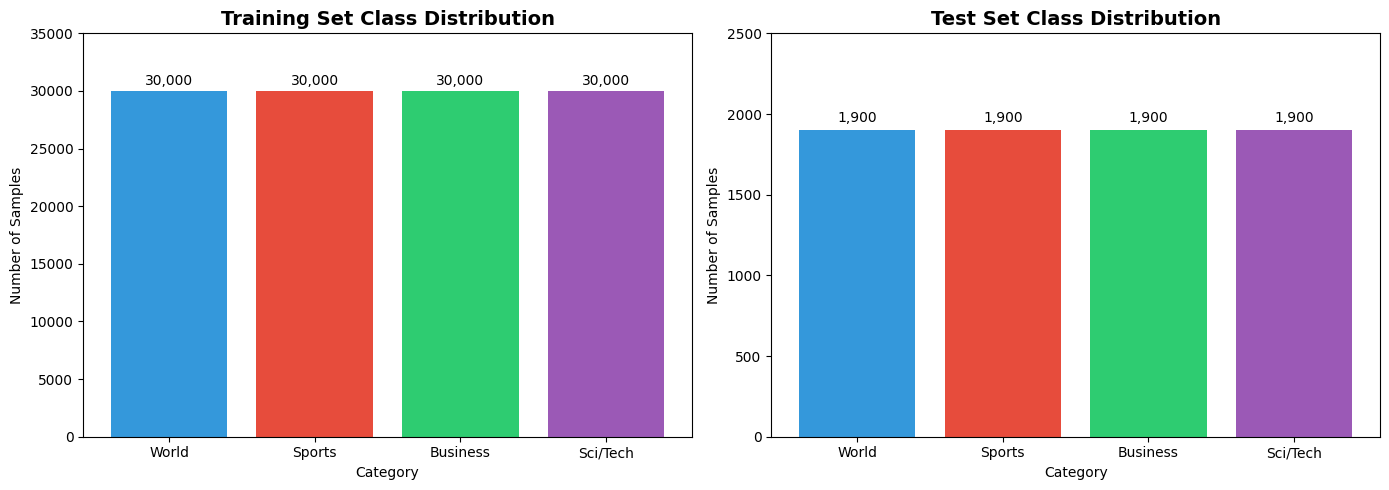


✅ Dataset is perfectly balanced with 30,000 samples per class in training set!


In [6]:
# Analyze class distribution
train_labels = [sample['label'] for sample in dataset['train']]
test_labels = [sample['label'] for sample in dataset['test']]

train_label_counts = Counter(train_labels)
test_label_counts = Counter(test_labels)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set class distribution
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
bars1 = axes[0].bar(LABEL_NAMES, [train_label_counts[i] for i in range(NUM_CLASSES)], color=colors)
axes[0].set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Samples')
axes[0].set_ylim(0, 35000)
for bar, count in zip(bars1, [train_label_counts[i] for i in range(NUM_CLASSES)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
                 f'{count:,}', ha='center', fontsize=10)

# Test set class distribution
bars2 = axes[1].bar(LABEL_NAMES, [test_label_counts[i] for i in range(NUM_CLASSES)], color=colors)
axes[1].set_title('Test Set Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of Samples')
axes[1].set_ylim(0, 2500)
for bar, count in zip(bars2, [test_label_counts[i] for i in range(NUM_CLASSES)]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                 f'{count:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Dataset is perfectly balanced with 30,000 samples per class in training set!")

Tokenizing training set:  16%|█▌        | 19179/120000 [00:00<00:01, 96447.99it/s]

Tokenizing training set: 100%|██████████| 120000/120000 [00:01<00:00, 97629.46it/s]


TEXT LENGTH STATISTICS (in tokens)
Mean length: 39.7 tokens
Median length: 39.0 tokens
Std deviation: 11.4 tokens
Min length: 12 tokens
Max length: 183 tokens
95th percentile: 58.0 tokens
99th percentile: 78.0 tokens


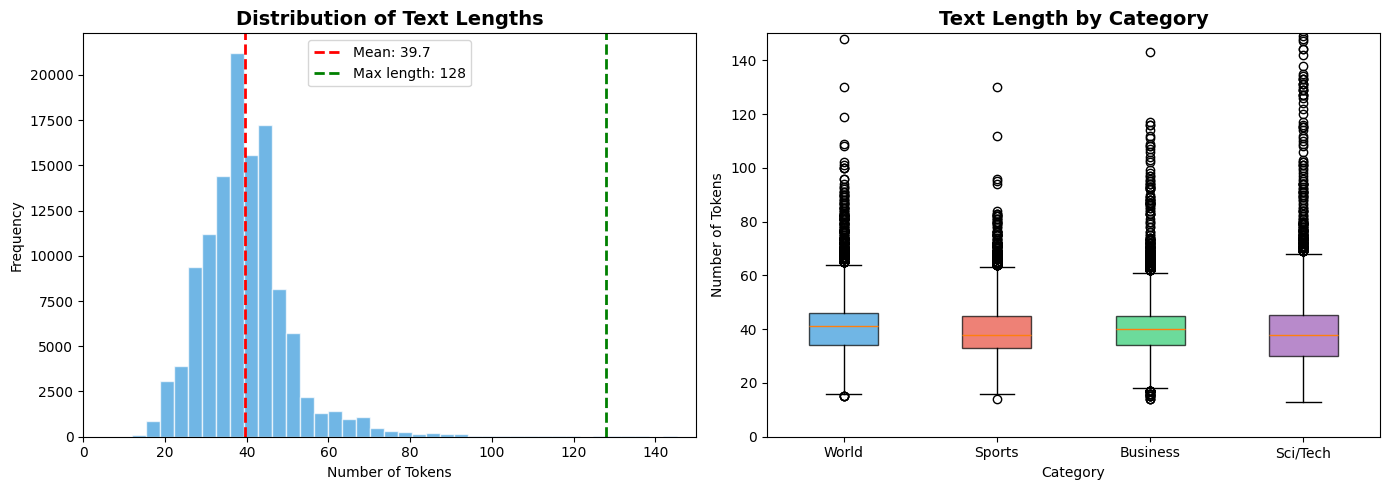


✅ Using MAX_SEQ_LENGTH = 128 (covers ~95% of samples)


In [7]:
# Simple tokenizer function (replaces torchtext's get_tokenizer)
def simple_tokenizer(text):
    """
    Basic English tokenizer that mimics torchtext's basic_english tokenizer.
    Converts to lowercase, removes punctuation, and splits on whitespace.
    """
    text = text.lower()
    # Replace punctuation with spaces
    text = re.sub(r'[^\w\s]', ' ', text)
    # Split on whitespace and filter empty strings
    tokens = [token for token in text.split() if token]
    return tokens

tokenizer = simple_tokenizer

# Calculate text lengths (in tokens)
train_lengths = [len(tokenizer(sample['text'])) for sample in tqdm(dataset['train'], desc="Tokenizing training set")]

# Text length statistics
print("=" * 60)
print("TEXT LENGTH STATISTICS (in tokens)")
print("=" * 60)
print(f"Mean length: {np.mean(train_lengths):.1f} tokens")
print(f"Median length: {np.median(train_lengths):.1f} tokens")
print(f"Std deviation: {np.std(train_lengths):.1f} tokens")
print(f"Min length: {np.min(train_lengths)} tokens")
print(f"Max length: {np.max(train_lengths)} tokens")
print(f"95th percentile: {np.percentile(train_lengths, 95):.1f} tokens")
print(f"99th percentile: {np.percentile(train_lengths, 99):.1f} tokens")

# Visualize text length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train_lengths, bins=50, color='#3498db', edgecolor='white', alpha=0.7)
axes[0].axvline(x=np.mean(train_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(train_lengths):.1f}')
axes[0].axvline(x=128, color='green', linestyle='--', linewidth=2, label='Max length: 128')
axes[0].set_title('Distribution of Text Lengths', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Tokens')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 150)

# Box plot by class
lengths_by_class = {label: [] for label in LABEL_NAMES}
for sample in dataset['train']:
    lengths_by_class[LABEL_NAMES[sample['label']]].append(len(tokenizer(sample['text'])))

box_data = [lengths_by_class[label][:5000] for label in LABEL_NAMES]  # Sample for speed
bp = axes[1].boxplot(box_data, labels=LABEL_NAMES, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Text Length by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of Tokens')
axes[1].set_ylim(0, 150)

plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Determine max sequence length
MAX_SEQ_LENGTH = 128
print(f"\n✅ Using MAX_SEQ_LENGTH = {MAX_SEQ_LENGTH} (covers ~95% of samples)")

### 2.2 Build Vocabulary

We'll create a vocabulary from the training data with special tokens for padding (`<PAD>`) and unknown words (`<UNK>`).

In [8]:
# Custom Vocabulary class (replaces torchtext's build_vocab_from_iterator)
class Vocabulary:
    """Simple vocabulary class to replace torchtext vocab."""
    
    def __init__(self, min_freq=1):
        self.word2idx = {}
        self.idx2word = {}
        self.word_freq = Counter()
        self.min_freq = min_freq
        
    def build_from_iterator(self, iterator, specials=['<PAD>', '<UNK>']):
        """Build vocabulary from an iterator of token lists."""
        # Count all words
        for tokens in tqdm(iterator, desc="Building vocabulary"):
            self.word_freq.update(tokens)
        
        # Add special tokens first
        for idx, token in enumerate(specials):
            self.word2idx[token] = idx
            self.idx2word[idx] = token
        
        # Add words that meet minimum frequency
        idx = len(specials)
        for word, freq in self.word_freq.items():
            if freq >= self.min_freq and word not in self.word2idx:
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                idx += 1
        
        self.default_idx = self.word2idx.get('<UNK>', 0)
        
    def set_default_index(self, idx):
        """Set the default index for unknown tokens."""
        self.default_idx = idx
        
    def __getitem__(self, token):
        """Get index for a token."""
        return self.word2idx.get(token, self.default_idx)
    
    def __len__(self):
        return len(self.word2idx)
    
    def __call__(self, tokens):
        """Convert a list of tokens to indices."""
        return [self[token] for token in tokens]


# Build vocabulary from training data
def yield_tokens(data_iter):
    """Generator that yields tokenized text"""
    for sample in data_iter:
        yield tokenizer(sample['text'])

# Build vocabulary with special tokens
# min_freq=3 filters out rare words that appear less than 3 times
print("Building vocabulary...")
vocab = Vocabulary(min_freq=3)
vocab.build_from_iterator(
    yield_tokens(dataset['train']),
    specials=['<PAD>', '<UNK>']
)

# Set default index for unknown tokens
vocab.set_default_index(vocab['<UNK>'])

VOCAB_SIZE = len(vocab)
PAD_IDX = vocab['<PAD>']
UNK_IDX = vocab['<UNK>']

print(f"\n✅ Vocabulary built successfully!")
print(f"   Vocabulary size: {VOCAB_SIZE:,}")
print(f"   PAD token index: {PAD_IDX}")
print(f"   UNK token index: {UNK_IDX}")

# Show some sample vocabulary words
print(f"\nSample vocabulary words:")
sample_words = ['the', 'news', 'sports', 'business', 'technology', 'world', 'market', 'game']
for word in sample_words:
    print(f"   '{word}' -> index {vocab[word]}")

Building vocabulary...


Building vocabulary: 120000it [00:01, 60336.80it/s]


✅ Vocabulary built successfully!
   Vocabulary size: 35,764
   PAD token index: 0
   UNK token index: 1

Sample vocabulary words:
   'the' -> index 8
   'news' -> index 466
   'sports' -> index 1263
   'business' -> index 736
   'technology' -> index 720
   'world' -> index 112
   'market' -> index 55
   'game' -> index 2717


### 2.3 Create PyTorch Dataset and DataLoaders

We'll create a custom Dataset class that:
1. Tokenizes the text
2. Converts tokens to indices using our vocabulary
3. Pads/truncates sequences to a fixed length

In [9]:
class AGNewsDataset(Dataset):
    """Custom Dataset for AG News classification"""
    
    def __init__(self, hf_dataset, vocab, tokenizer, max_length=128):
        """
        Args:
            hf_dataset: Hugging Face dataset split
            vocab: torchtext vocabulary
            tokenizer: tokenizer function
            max_length: maximum sequence length
        """
        self.data = list(hf_dataset)
        self.vocab = vocab
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data[idx]
        text = sample['text']
        label = sample['label']
        
        # Tokenize and convert to indices
        tokens = self.tokenizer(text)
        indices = self.vocab(tokens)
        
        # Truncate if too long
        if len(indices) > self.max_length:
            indices = indices[:self.max_length]
        
        # Calculate actual length before padding
        seq_length = len(indices)
        
        # Pad if too short
        if len(indices) < self.max_length:
            indices = indices + [self.vocab['<PAD>']] * (self.max_length - len(indices))
        
        return {
            'input_ids': torch.tensor(indices, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.long),
            'length': torch.tensor(seq_length, dtype=torch.long),
            'text': text,  # Keep original text for attention visualization
            'tokens': tokens[:self.max_length]  # Keep tokens for visualization
        }

def collate_fn(batch):
    """Custom collate function for DataLoader"""
    input_ids = torch.stack([item['input_ids'] for item in batch])
    labels = torch.stack([item['label'] for item in batch])
    lengths = torch.stack([item['length'] for item in batch])
    texts = [item['text'] for item in batch]
    tokens = [item['tokens'] for item in batch]
    
    return {
        'input_ids': input_ids,
        'labels': labels,
        'lengths': lengths,
        'texts': texts,
        'tokens': tokens
    }

In [10]:
# Create datasets
print("Creating datasets...")

# Create full training dataset
full_train_dataset = AGNewsDataset(dataset['train'], vocab, tokenizer, MAX_SEQ_LENGTH)
test_dataset = AGNewsDataset(dataset['test'], vocab, tokenizer, MAX_SEQ_LENGTH)

# Split training into train and validation (90/10 split)
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"\n✅ Datasets created:")
print(f"   Training samples: {len(train_dataset):,}")
print(f"   Validation samples: {len(val_dataset):,}")
print(f"   Test samples: {len(test_dataset):,}")

# Create DataLoaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\n✅ DataLoaders created with batch size {BATCH_SIZE}")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

Creating datasets...

✅ Datasets created:
   Training samples: 108,000
   Validation samples: 12,000
   Test samples: 7,600

✅ DataLoaders created with batch size 64
   Training batches: 1688
   Validation batches: 188
   Test batches: 119


In [11]:
# Verify a sample batch
sample_batch = next(iter(train_loader))
print("Sample batch structure:")
print(f"   input_ids shape: {sample_batch['input_ids'].shape}")
print(f"   labels shape: {sample_batch['labels'].shape}")
print(f"   lengths shape: {sample_batch['lengths'].shape}")
print(f"\nSample input_ids[0][:20]: {sample_batch['input_ids'][0][:20].tolist()}")
print(f"Sample label[0]: {sample_batch['labels'][0].item()} ({LABEL_NAMES[sample_batch['labels'][0].item()]})")
print(f"Sample length[0]: {sample_batch['lengths'][0].item()}")

Sample batch structure:
   input_ids shape: torch.Size([64, 128])
   labels shape: torch.Size([64])
   lengths shape: torch.Size([64])

Sample input_ids[0][:20]: [874, 4724, 2717, 9015, 4648, 199, 4864, 684, 4864, 684, 4629, 21410, 23697, 6148, 35, 545, 1885, 2924, 45, 8]
Sample label[0]: 1 (Sports)
Sample length[0]: 51


## 3. Kaiming (He) Initialization

### Theory Behind Kaiming Initialization

Kaiming initialization (also known as He initialization) is designed to address the vanishing/exploding gradient problem in deep networks with ReLU activations.

**Key Insight**: For layers using ReLU activation, the standard Xavier initialization doesn't account for the fact that ReLU zeros out half of the inputs (negative values). This causes the variance to shrink by half at each layer.

**Mathematical Formulation**:

For a layer with $n_{in}$ input units, weights are drawn from:

$$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{in}}}\right)$$

This ensures that:
- The variance of activations remains constant across layers
- Gradients don't vanish or explode during backpropagation
- The network can be trained more effectively, especially in deeper architectures

**Modes**:
- **fan_in** (default): Preserves variance in forward pass
- **fan_out**: Preserves variance in backward pass (useful for backprop)

In [12]:
def kaiming_init_weights(module, mode='fan_in', nonlinearity='relu'):
    """
    Apply Kaiming (He) initialization to a module's weights.
    
    For ReLU activations, weights are initialized from:
        W ~ N(0, sqrt(2 / fan_in))  for fan_in mode
        W ~ N(0, sqrt(2 / fan_out)) for fan_out mode
    
    Args:
        module: PyTorch module to initialize
        mode: 'fan_in' or 'fan_out'
        nonlinearity: the non-linear function (relu or leaky_relu)
    """
    if isinstance(module, nn.Linear):
        # Kaiming normal initialization for linear layers
        nn.init.kaiming_normal_(module.weight, mode=mode, nonlinearity=nonlinearity)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
            
    elif isinstance(module, nn.LSTM) or isinstance(module, nn.GRU):
        # For RNN layers, apply Kaiming to weight matrices
        for name, param in module.named_parameters():
            if 'weight_ih' in name:  # Input-hidden weights
                nn.init.kaiming_normal_(param.data, mode=mode, nonlinearity=nonlinearity)
            elif 'weight_hh' in name:  # Hidden-hidden weights
                nn.init.orthogonal_(param.data)  # Orthogonal init for recurrent weights
            elif 'bias' in name:
                nn.init.zeros_(param.data)
                # Set forget gate bias to 1 for LSTM (helps with long-term dependencies)
                if isinstance(module, nn.LSTM):
                    hidden_size = module.hidden_size
                    param.data[hidden_size:2*hidden_size].fill_(1.0)
                    
    elif isinstance(module, nn.Embedding):
        # Xavier uniform for embeddings (commonly used)
        nn.init.xavier_uniform_(module.weight)
        if module.padding_idx is not None:
            module.weight.data[module.padding_idx].fill_(0)

def init_model_weights(model, mode='fan_in', nonlinearity='relu'):
    """
    Apply Kaiming initialization to all layers in the model.
    
    Args:
        model: PyTorch model
        mode: 'fan_in' or 'fan_out'
        nonlinearity: activation function type
    """
    for name, module in model.named_modules():
        kaiming_init_weights(module, mode, nonlinearity)
    
    return model

# Demonstrate Kaiming initialization
print("=" * 60)
print("KAIMING INITIALIZATION DEMONSTRATION")
print("=" * 60)

# Create sample layers
linear_layer = nn.Linear(512, 256)
print(f"\nBefore Kaiming init (Linear 512->256):")
print(f"   Weight mean: {linear_layer.weight.mean().item():.6f}")
print(f"   Weight std:  {linear_layer.weight.std().item():.6f}")
print(f"   Expected std (Kaiming): {np.sqrt(2/512):.6f}")

# Apply Kaiming initialization
nn.init.kaiming_normal_(linear_layer.weight, mode='fan_in', nonlinearity='relu')
print(f"\nAfter Kaiming init:")
print(f"   Weight mean: {linear_layer.weight.mean().item():.6f}")
print(f"   Weight std:  {linear_layer.weight.std().item():.6f}")

print("\n✅ Kaiming initialization preserves variance through deep networks!")

KAIMING INITIALIZATION DEMONSTRATION

Before Kaiming init (Linear 512->256):
   Weight mean: 0.000080
   Weight std:  0.025527
   Expected std (Kaiming): 0.062500

After Kaiming init:
   Weight mean: -0.000007
   Weight std:  0.062436

✅ Kaiming initialization preserves variance through deep networks!


## 4. BiLSTM + Attention Model Architecture

Our model consists of 4 main components:

1. **Embedding Layer**: Converts token indices to dense vectors (300d)
2. **Bidirectional LSTM**: 2-layer BiLSTM (256 hidden units) captures sequential context from both directions
3. **Self-Attention Layer**: Learns to weight important words for classification
4. **Classifier**: Fully connected layers with dropout for final prediction

### Architecture Diagram:
```
Input Tokens → Embedding (300d) → BiLSTM (2 layers, 256 hidden) 
            → Self-Attention → Weighted Sum → FC(512→256) → ReLU 
            → Dropout → FC(256→4) → Softmax
```

This architecture has **3+ layers with nonlinear activations** (LSTM tanh/sigmoid, ReLU, Softmax).

In [13]:
class SelfAttention(nn.Module):
    """
    Self-Attention mechanism for sequence classification.
    
    Computes attention weights over the sequence and returns
    a weighted sum of the hidden states.
    """
    
    def __init__(self, hidden_size):
        super(SelfAttention, self).__init__()
        self.hidden_size = hidden_size
        
        # Attention layers
        self.W = nn.Linear(hidden_size, hidden_size)
        self.V = nn.Linear(hidden_size, 1, bias=False)
        
    def forward(self, hidden_states, mask=None):
        """
        Args:
            hidden_states: (batch_size, seq_len, hidden_size)
            mask: (batch_size, seq_len) - 1 for valid tokens, 0 for padding
            
        Returns:
            context: (batch_size, hidden_size) - weighted sum
            attention_weights: (batch_size, seq_len) - attention scores
        """
        # Compute attention scores
        # hidden_states: (batch, seq_len, hidden_size)
        energy = torch.tanh(self.W(hidden_states))  # (batch, seq_len, hidden_size)
        attention_scores = self.V(energy).squeeze(-1)  # (batch, seq_len)
        
        # Apply mask to ignore padding tokens
        if mask is not None:
            attention_scores = attention_scores.masked_fill(mask == 0, float('-inf'))
        
        # Softmax to get attention weights
        attention_weights = F.softmax(attention_scores, dim=1)  # (batch, seq_len)
        
        # Weighted sum of hidden states
        context = torch.bmm(attention_weights.unsqueeze(1), hidden_states)  # (batch, 1, hidden_size)
        context = context.squeeze(1)  # (batch, hidden_size)
        
        return context, attention_weights


class BiLSTMAttentionClassifier(nn.Module):
    """
    Bidirectional LSTM with Self-Attention for Text Classification.
    
    Architecture:
        Embedding → BiLSTM (2 layers) → Self-Attention → FC → Output
    """
    
    def __init__(
        self,
        vocab_size,
        embedding_dim=300,
        hidden_size=256,
        num_layers=2,
        num_classes=4,
        dropout=0.5,
        padding_idx=0
    ):
        super(BiLSTMAttentionClassifier, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.num_directions = 2  # Bidirectional
        
        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=padding_idx
        )
        
        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Self-Attention layer
        self.attention = SelfAttention(hidden_size * 2)  # *2 for bidirectional
        
        # Classifier layers
        self.fc1 = nn.Linear(hidden_size * 2, 256)
        self.fc2 = nn.Linear(256, num_classes)
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
        # Layer normalization for stability
        self.layer_norm = nn.LayerNorm(hidden_size * 2)
        
    def forward(self, input_ids, lengths=None, return_attention=False):
        """
        Forward pass.
        
        Args:
            input_ids: (batch_size, seq_len) - token indices
            lengths: (batch_size,) - actual sequence lengths (before padding)
            return_attention: whether to return attention weights
            
        Returns:
            logits: (batch_size, num_classes)
            attention_weights: (batch_size, seq_len) if return_attention=True
        """
        batch_size, seq_len = input_ids.shape
        
        # Create mask for padding tokens
        mask = (input_ids != 0).float()  # (batch, seq_len)
        
        # Embedding
        embedded = self.embedding(input_ids)  # (batch, seq_len, embed_dim)
        embedded = self.dropout(embedded)
        
        # Pack sequences for efficient LSTM processing (optional)
        # For simplicity, we'll use the mask-based approach
        
        # BiLSTM
        lstm_out, (hidden, cell) = self.lstm(embedded)
        # lstm_out: (batch, seq_len, hidden_size * 2)
        
        # Layer normalization
        lstm_out = self.layer_norm(lstm_out)
        
        # Self-Attention
        context, attention_weights = self.attention(lstm_out, mask)
        # context: (batch, hidden_size * 2)
        
        # Classifier
        x = self.dropout(context)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        logits = self.fc2(x)  # (batch, num_classes)
        
        if return_attention:
            return logits, attention_weights
        return logits
    
    def get_attention_weights(self, input_ids):
        """Helper method to extract attention weights for visualization."""
        self.eval()
        with torch.no_grad():
            _, attention_weights = self.forward(input_ids, return_attention=True)
        return attention_weights

In [14]:
# Model hyperparameters
EMBEDDING_DIM = 300
HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.5

# Initialize model
model = BiLSTMAttentionClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
    padding_idx=PAD_IDX
)

# Apply Kaiming initialization
model = init_model_weights(model, mode='fan_in', nonlinearity='relu')

# Move model to device
model = model.to(device)

# Count parameters
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model)

print("=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)
print(model)
print("\n" + "=" * 60)
print("MODEL STATISTICS")
print("=" * 60)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Embedding parameters: {VOCAB_SIZE * EMBEDDING_DIM:,}")
print(f"LSTM parameters: {sum(p.numel() for n, p in model.named_parameters() if 'lstm' in n):,}")
print(f"Attention parameters: {sum(p.numel() for n, p in model.named_parameters() if 'attention' in n):,}")
print(f"FC parameters: {sum(p.numel() for n, p in model.named_parameters() if 'fc' in n):,}")

MODEL ARCHITECTURE
BiLSTMAttentionClassifier(
  (embedding): Embedding(35764, 300, padding_idx=0)
  (lstm): LSTM(300, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): SelfAttention(
    (W): Linear(in_features=512, out_features=512, bias=True)
    (V): Linear(in_features=512, out_features=1, bias=False)
  )
  (fc1): Linear(in_features=512, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=4, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
)

MODEL STATISTICS
Total parameters: 13,845,492
Trainable parameters: 13,845,492
Embedding parameters: 10,729,200
LSTM parameters: 2,719,744
Attention parameters: 263,168
FC parameters: 132,356


In [15]:
# Test forward pass
print("\nTesting forward pass...")
sample_batch = next(iter(train_loader))
sample_input = sample_batch['input_ids'].to(device)
sample_lengths = sample_batch['lengths'].to(device)

with torch.no_grad():
    logits, attention = model(sample_input, sample_lengths, return_attention=True)

print(f"Input shape: {sample_input.shape}")
print(f"Output logits shape: {logits.shape}")
print(f"Attention weights shape: {attention.shape}")
print(f"Sample predictions: {torch.argmax(logits[:5], dim=1).tolist()}")
print(f"Attention sum (should be ~1.0): {attention[0].sum().item():.4f}")
print("\n✅ Model forward pass successful!")


Testing forward pass...
Input shape: torch.Size([64, 128])
Output logits shape: torch.Size([64, 4])
Attention weights shape: torch.Size([64, 128])
Sample predictions: [1, 3, 1, 1, 2]
Attention sum (should be ~1.0): 1.0000

✅ Model forward pass successful!


## 5. Creative Enhancement #1: Easy Data Augmentation (EDA)

**Easy Data Augmentation** improves model robustness by creating variations of training samples through:

1. **Synonym Replacement (SR)**: Replace random words with their synonyms
2. **Random Swap (RS)**: Randomly swap positions of two words
3. **Random Deletion (RD)**: Randomly delete words with a probability

This helps the model generalize better by exposing it to more diverse text patterns.

In [16]:
# Simple synonym dictionary for common news words
# (In production, you'd use WordNet or a larger synonym database)
SYNONYMS = {
    'good': ['great', 'excellent', 'positive', 'favorable'],
    'bad': ['poor', 'negative', 'unfavorable', 'terrible'],
    'big': ['large', 'huge', 'major', 'significant'],
    'small': ['little', 'minor', 'tiny', 'slight'],
    'new': ['recent', 'latest', 'fresh', 'modern'],
    'old': ['previous', 'former', 'ancient', 'past'],
    'increase': ['rise', 'grow', 'surge', 'jump'],
    'decrease': ['fall', 'drop', 'decline', 'reduce'],
    'company': ['firm', 'corporation', 'business', 'enterprise'],
    'market': ['trading', 'exchange', 'marketplace'],
    'said': ['stated', 'announced', 'reported', 'declared'],
    'government': ['administration', 'authorities', 'regime'],
    'president': ['leader', 'chief', 'head'],
    'country': ['nation', 'state', 'land'],
    'people': ['individuals', 'citizens', 'population'],
    'year': ['period', 'annum', 'fiscal year'],
    'game': ['match', 'contest', 'competition'],
    'team': ['squad', 'club', 'side'],
    'win': ['victory', 'triumph', 'succeed'],
    'technology': ['tech', 'innovation', 'digital'],
    'research': ['study', 'investigation', 'analysis'],
    'scientists': ['researchers', 'experts', 'investigators'],
}

# Build reverse lookup
WORD_TO_SYNONYMS = {}
for word, syns in SYNONYMS.items():
    WORD_TO_SYNONYMS[word] = syns
    for syn in syns:
        if syn not in WORD_TO_SYNONYMS:
            WORD_TO_SYNONYMS[syn] = [word] + [s for s in syns if s != syn]


class EasyDataAugmentation:
    """
    Easy Data Augmentation (EDA) for text classification.
    
    Implements three augmentation techniques:
    1. Synonym Replacement (SR)
    2. Random Swap (RS)  
    3. Random Deletion (RD)
    """
    
    def __init__(self, p_sr=0.1, p_rs=0.1, p_rd=0.1):
        """
        Args:
            p_sr: probability of synonym replacement per word
            p_rs: probability of random swap
            p_rd: probability of random deletion per word
        """
        self.p_sr = p_sr
        self.p_rs = p_rs
        self.p_rd = p_rd
        
    def synonym_replacement(self, tokens):
        """Replace random words with synonyms."""
        new_tokens = tokens.copy()
        for i, token in enumerate(new_tokens):
            if random.random() < self.p_sr and token.lower() in WORD_TO_SYNONYMS:
                synonyms = WORD_TO_SYNONYMS[token.lower()]
                new_tokens[i] = random.choice(synonyms)
        return new_tokens
    
    def random_swap(self, tokens):
        """Randomly swap two words in the sentence."""
        new_tokens = tokens.copy()
        if len(new_tokens) < 2:
            return new_tokens
            
        n_swaps = max(1, int(len(new_tokens) * self.p_rs))
        for _ in range(n_swaps):
            idx1, idx2 = random.sample(range(len(new_tokens)), 2)
            new_tokens[idx1], new_tokens[idx2] = new_tokens[idx2], new_tokens[idx1]
        return new_tokens
    
    def random_deletion(self, tokens):
        """Randomly delete words from the sentence."""
        if len(tokens) <= 1:
            return tokens
            
        new_tokens = [token for token in tokens if random.random() > self.p_rd]
        
        # Ensure at least one word remains
        if len(new_tokens) == 0:
            return [random.choice(tokens)]
        return new_tokens
    
    def augment(self, text, tokenizer, num_aug=1):
        """
        Apply EDA augmentation to a text.
        
        Args:
            text: input text string
            tokenizer: tokenizer function
            num_aug: number of augmented samples to generate
            
        Returns:
            list of augmented texts
        """
        tokens = tokenizer(text)
        augmented_texts = []
        
        for _ in range(num_aug):
            aug_tokens = tokens.copy()
            
            # Apply augmentations
            if random.random() < 0.5:
                aug_tokens = self.synonym_replacement(aug_tokens)
            if random.random() < 0.5:
                aug_tokens = self.random_swap(aug_tokens)
            if random.random() < 0.5:
                aug_tokens = self.random_deletion(aug_tokens)
            
            augmented_texts.append(' '.join(aug_tokens))
        
        return augmented_texts


# Demonstrate EDA
print("=" * 60)
print("EASY DATA AUGMENTATION (EDA) DEMONSTRATION")
print("=" * 60)

eda = EasyDataAugmentation(p_sr=0.2, p_rs=0.1, p_rd=0.1)

# Sample text from dataset
sample_text = dataset['train'][0]['text']
print(f"\nOriginal text:")
print(f"  {sample_text[:200]}...")

print(f"\nAugmented versions:")
for i, aug_text in enumerate(eda.augment(sample_text, tokenizer, num_aug=3)):
    print(f"\n  Version {i+1}:")
    print(f"  {aug_text[:200]}...")

EASY DATA AUGMENTATION (EDA) DEMONSTRATION

Original text:
  Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again....

Augmented versions:

  Version 1:
  wall st bears claw reuters into the back black reuters short sellers wall street s dwindling band of ultra cynics are seeing green again...

  Version 2:
  wall bears claw into the black reuters reuters short wall street s dwindling band of are seeing green again...

  Version 3:
  wall st bears claw back into black reuters short sellers wall street s dwindling band of ultra cynics are seeing green again...


In [17]:
class AugmentedAGNewsDataset(Dataset):
    """
    AG News Dataset with Easy Data Augmentation.
    
    Applies EDA to a subset of training samples to increase diversity.
    """
    
    def __init__(self, hf_dataset, vocab, tokenizer, max_length=128, 
                 augment_ratio=0.25, eda=None):
        """
        Args:
            hf_dataset: Hugging Face dataset split
            vocab: torchtext vocabulary
            tokenizer: tokenizer function
            max_length: maximum sequence length
            augment_ratio: fraction of data to augment
            eda: EasyDataAugmentation instance
        """
        self.vocab = vocab
        self.tokenizer = tokenizer
        self.max_length = max_length
        
        # Original data
        self.data = []
        for sample in hf_dataset:
            self.data.append({
                'text': sample['text'],
                'label': sample['label']
            })
        
        # Apply augmentation to subset
        if eda is not None and augment_ratio > 0:
            n_augment = int(len(self.data) * augment_ratio)
            indices_to_augment = random.sample(range(len(self.data)), n_augment)
            
            augmented_samples = []
            for idx in indices_to_augment:
                original = self.data[idx]
                aug_texts = eda.augment(original['text'], tokenizer, num_aug=1)
                for aug_text in aug_texts:
                    augmented_samples.append({
                        'text': aug_text,
                        'label': original['label']
                    })
            
            self.data.extend(augmented_samples)
            print(f"Added {len(augmented_samples)} augmented samples")
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data[idx]
        text = sample['text']
        label = sample['label']
        
        # Tokenize and convert to indices
        tokens = self.tokenizer(text)
        indices = self.vocab(tokens)
        
        # Truncate if too long
        if len(indices) > self.max_length:
            indices = indices[:self.max_length]
        
        seq_length = len(indices)
        
        # Pad if too short
        if len(indices) < self.max_length:
            indices = indices + [self.vocab['<PAD>']] * (self.max_length - len(indices))
        
        return {
            'input_ids': torch.tensor(indices, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.long),
            'length': torch.tensor(seq_length, dtype=torch.long),
            'text': text,
            'tokens': tokens[:self.max_length]
        }


# Create augmented training dataset
print("Creating augmented training dataset...")
eda = EasyDataAugmentation(p_sr=0.15, p_rs=0.1, p_rd=0.1)

augmented_train_dataset = AugmentedAGNewsDataset(
    dataset['train'],
    vocab,
    tokenizer,
    MAX_SEQ_LENGTH,
    augment_ratio=0.25,  # Augment 25% of training data
    eda=eda
)

print(f"\n✅ Augmented dataset size: {len(augmented_train_dataset):,}")
print(f"   Original size: 120,000")
print(f"   Added samples: {len(augmented_train_dataset) - 120000:,}")

# Create new DataLoader with augmented data
augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"   Augmented training batches: {len(augmented_train_loader)}")

Creating augmented training dataset...
Added 30000 augmented samples

✅ Augmented dataset size: 150,000
   Original size: 120,000
   Added samples: 30,000
   Augmented training batches: 2344


## 6. Creative Enhancement #2: Label Smoothing

**Label Smoothing** is a regularization technique that prevents the model from becoming overconfident in its predictions.

### How it works:
Instead of training with hard labels like `[0, 0, 1, 0]` (100% Business), we use soft labels like `[0.033, 0.033, 0.9, 0.033]`.

### Benefits:
- **Prevents overconfidence**: Model doesn't learn to predict extreme probabilities
- **Better generalization**: Reduces overfitting to training data
- **Improved calibration**: Predicted probabilities are more meaningful

In [18]:
class LabelSmoothingLoss(nn.Module):
    """
    Label Smoothing Loss for classification.
    
    Instead of using hard labels [0, 0, 1, 0], uses soft labels like [0.033, 0.033, 0.9, 0.033].
    This prevents the model from becoming overconfident and improves generalization.
    
    Mathematical formulation:
        smooth_label = (1 - smoothing) * one_hot + smoothing / num_classes
    """
    
    def __init__(self, num_classes=4, smoothing=0.1):
        """
        Args:
            num_classes: Number of classes
            smoothing: Smoothing factor (0.0 = no smoothing, 1.0 = uniform distribution)
        """
        super().__init__()
        self.smoothing = smoothing
        self.num_classes = num_classes
        self.confidence = 1.0 - smoothing
        
    def forward(self, pred, target):
        """
        Args:
            pred: Model predictions (logits), shape (batch_size, num_classes)
            target: Ground truth labels, shape (batch_size,)
            
        Returns:
            Smoothed cross-entropy loss
        """
        # Create one-hot encoding
        one_hot = torch.zeros_like(pred).scatter_(1, target.unsqueeze(1), 1)
        
        # Apply label smoothing
        smooth_value = self.smoothing / (self.num_classes - 1)
        smooth_target = one_hot * self.confidence + (1 - one_hot) * smooth_value
        
        # Compute log softmax
        log_prob = F.log_softmax(pred, dim=-1)
        
        # Compute smoothed loss
        loss = (-smooth_target * log_prob).sum(dim=-1).mean()
        
        return loss


# Demonstrate Label Smoothing
print("=" * 60)
print("LABEL SMOOTHING DEMONSTRATION")
print("=" * 60)

# Example: Compare hard vs smooth labels
hard_label = torch.tensor([2])  # Business class
one_hot = torch.zeros(1, 4).scatter_(1, hard_label.unsqueeze(1), 1)
print(f"\nHard label (one-hot): {one_hot[0].tolist()}")

smoothing = 0.1
smooth_value = smoothing / 3  # 3 = num_classes - 1
smooth_label = one_hot * (1 - smoothing) + (1 - one_hot) * smooth_value
print(f"Smooth label (ε=0.1): {[f'{x:.3f}' for x in smooth_label[0].tolist()]}")

print("\n✅ Label smoothing will be used during training for better generalization!")

LABEL SMOOTHING DEMONSTRATION

Hard label (one-hot): [0.0, 0.0, 1.0, 0.0]
Smooth label (ε=0.1): ['0.033', '0.033', '0.900', '0.033']

✅ Label smoothing will be used during training for better generalization!


## 7. Training Pipeline

We'll train the model with:
- **Optimizer**: Adam with learning rate 1e-3
- **Loss**: Label Smoothing Loss (Enhancement #2) for better calibration
- **Gradient Clipping**: Max norm 1.0 (prevents exploding gradients in RNNs)
- **Early Stopping**: Stop if validation loss doesn't improve for 3 epochs
- **Model Checkpointing**: Save the best model based on validation accuracy

In [19]:
def train_epoch(model, data_loader, optimizer, criterion, device, clip_grad=1.0):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    progress_bar = tqdm(data_loader, desc="Training", leave=False)
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)
        lengths = batch['lengths'].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        logits = model(input_ids, lengths)
        
        # Compute loss
        loss = criterion(logits, labels)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        
        # Update weights
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item() * input_ids.size(0)
        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == labels).sum().item()
        total += input_ids.size(0)
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100*correct/total:.2f}%'
        })
    
    avg_loss = total_loss / total
    accuracy = correct / total
    
    return avg_loss, accuracy


def evaluate(model, data_loader, criterion, device):
    """Evaluate the model."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating", leave=False):
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            lengths = batch['lengths'].to(device)
            
            # Forward pass
            logits = model(input_ids, lengths)
            
            # Compute loss
            loss = criterion(logits, labels)
            
            # Track metrics
            total_loss += loss.item() * input_ids.size(0)
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == labels).sum().item()
            total += input_ids.size(0)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / total
    accuracy = correct / total
    
    return avg_loss, accuracy, all_predictions, all_labels


class EarlyStopping:
    """Early stopping to prevent overfitting."""
    
    def __init__(self, patience=3, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [20]:
# Training configuration
LEARNING_RATE = 1e-3
NUM_EPOCHS = 10
CLIP_GRAD = 1.0
PATIENCE = 3
LABEL_SMOOTHING = 0.1

# Loss function with Label Smoothing (Creative Enhancement #2)
criterion = LabelSmoothingLoss(num_classes=NUM_CLASSES, smoothing=LABEL_SMOOTHING)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# Early stopping
early_stopping = EarlyStopping(patience=PATIENCE)

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

# Best model tracking
best_val_acc = 0
best_model_state = None

print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)
print(f"Learning rate: {LEARNING_RATE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Gradient clipping: {CLIP_GRAD}")
print(f"Early stopping patience: {PATIENCE}")
print(f"Label smoothing: {LABEL_SMOOTHING}")
print(f"Device: {device}")
print(f"Using augmented data: Yes (25% augmentation)")
print("=" * 60)

TRAINING CONFIGURATION
Learning rate: 0.001
Epochs: 10
Batch size: 64
Gradient clipping: 1.0
Early stopping patience: 3
Label smoothing: 0.1
Device: cuda
Using augmented data: Yes (25% augmentation)


In [21]:
# Training loop
print("\n🚀 Starting training...\n")

for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)
    
    # Train
    train_loss, train_acc = train_epoch(
        model, augmented_train_loader, optimizer, criterion, device, CLIP_GRAD
    )
    
    # Validate
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    
    # Update learning rate
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print epoch summary
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {100*train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {100*val_acc:.2f}%")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        print(f"✅ New best model saved! (Val Acc: {100*best_val_acc:.2f}%)")
    
    # Early stopping check
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
        break
    
    print()

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\n✅ Loaded best model with validation accuracy: {100*best_val_acc:.2f}%")


🚀 Starting training...

Epoch 1/10
----------------------------------------


Train Loss: 1.0079 | Train Acc: 60.50%
Val Loss:   0.5806 | Val Acc:   92.76%
✅ New best model saved! (Val Acc: 92.76%)

Epoch 2/10
----------------------------------------


Train Loss: 0.6038 | Train Acc: 92.84%
Val Loss:   0.5369 | Val Acc:   95.00%
✅ New best model saved! (Val Acc: 95.00%)

Epoch 3/10
----------------------------------------


Train Loss: 0.5577 | Train Acc: 94.90%
Val Loss:   0.5156 | Val Acc:   96.13%
✅ New best model saved! (Val Acc: 96.13%)

Epoch 4/10
----------------------------------------


Train Loss: 0.5289 | Train Acc: 96.19%
Val Loss:   0.4912 | Val Acc:   97.30%
✅ New best model saved! (Val Acc: 97.30%)

Epoch 5/10
----------------------------------------


...

Train Loss: 0.4944 | Train Acc: 97.81%
Val Loss:   0.4722 | Val Acc:   98.39%
✅ New best model saved! (Val Acc: 98.39%)

Epoch 7/10
----------------------------------------


Train Loss: 0.4833 | Train Acc: 98.27%
Val Loss:   0.4633 | Val Acc:   98.75%
✅ New best model saved! (Val Acc: 98.75%)

Epoch 8/10
----------------------------------------


Train Loss: 0.4764 | Train Acc: 98.57%
Val Loss:   0.4599 | Val Acc:   98.89%
✅ New best model saved! (Val Acc: 98.89%)

Epoch 9/10
----------------------------------------


Train Loss: 0.4707 | Train Acc: 98.83%
Val Loss:   0.4545 | Val Acc:   99.16%
✅ New best model saved! (Val Acc: 99.16%)

Epoch 10/10
----------------------------------------


Train Loss: 0.4672 | Train Acc: 98.93%
Val Loss:   0.4519 | Val Acc:   99.30%
✅ New best model saved! (Val Acc: 99.30%)


✅ Loaded best model with validation accuracy: 99.30%


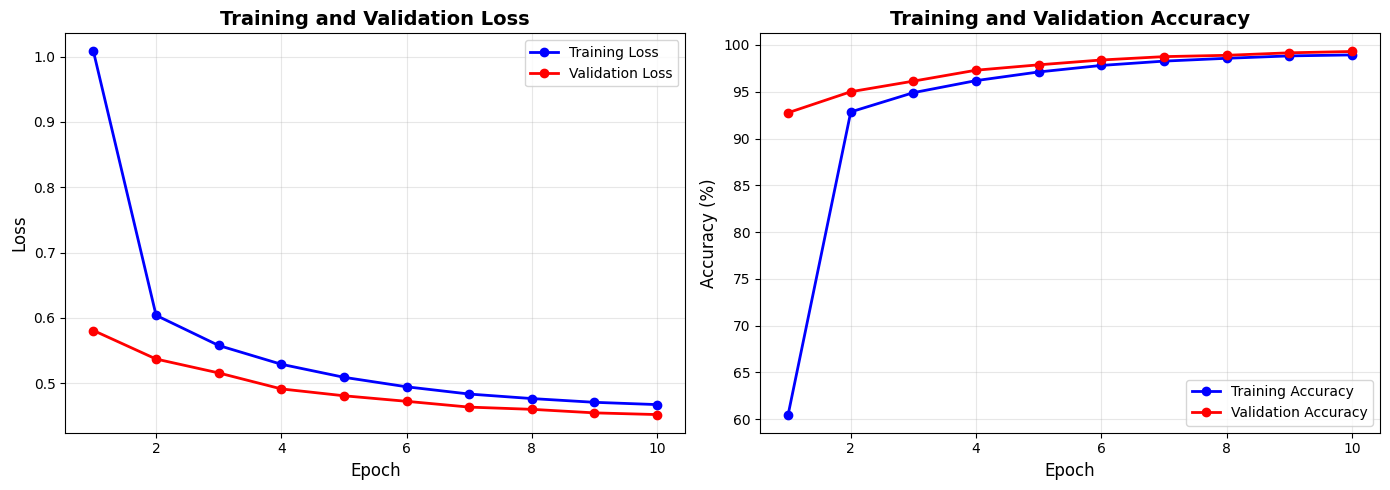

In [22]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss plot
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Training Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], 'r-o', label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs_range, [acc*100 for acc in history['train_acc']], 'b-o', label='Training Accuracy', linewidth=2)
axes[1].plot(epochs_range, [acc*100 for acc in history['val_acc']], 'r-o', label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Model Evaluation on Test Set

Let's evaluate the trained model on the held-out test set and analyze its performance using:
- **Classification Report**: Precision, Recall, F1-score per class
- **Confusion Matrix**: Visual breakdown of predictions vs actual labels
- **Per-class Accuracy**: Individual class performance

In [35]:
# Evaluate on test set
print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)

test_loss, test_acc, test_predictions, test_labels = evaluate(
    model, test_loader, criterion, device
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {100*test_acc:.2f}%")

# Classification report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(test_labels, test_predictions, target_names=LABEL_NAMES, digits=4))

# Per-class accuracy
print("\n" + "=" * 60)
print("PER-CLASS PERFORMANCE")
print("=" * 60)
for i, label in enumerate(LABEL_NAMES):
    class_mask = np.array(test_labels) == i
    class_acc = np.mean(np.array(test_predictions)[class_mask] == i)
    print(f"{label:12}: {100*class_acc:.2f}% accuracy")

TEST SET EVALUATION



Test Loss: 0.6377
Test Accuracy: 91.34%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       World     0.9354    0.9074    0.9212      1900
      Sports     0.9685    0.9705    0.9695      1900
    Business     0.8674    0.8916    0.8793      1900
    Sci/Tech     0.8842    0.8842    0.8842      1900

    accuracy                         0.9134      7600
   macro avg     0.9139    0.9134    0.9136      7600
weighted avg     0.9139    0.9134    0.9136      7600


PER-CLASS PERFORMANCE
World       : 90.74% accuracy
Sports      : 97.05% accuracy
Business    : 89.16% accuracy
Sci/Tech    : 88.42% accuracy


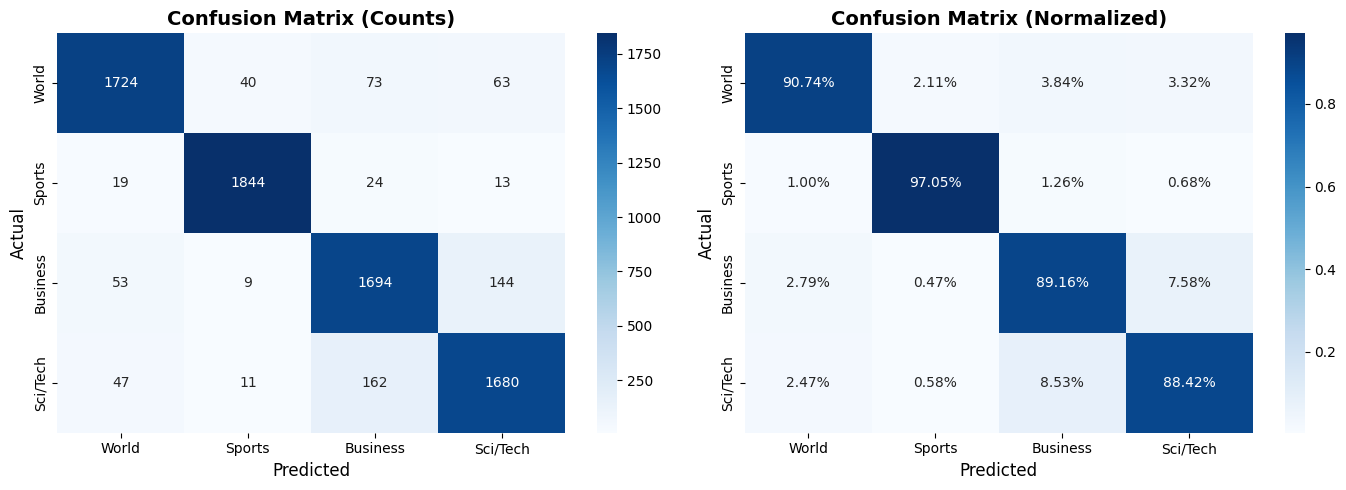


Macro F1 Score: 0.9136
Weighted F1 Score: 0.9136


In [36]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABEL_NAMES, 
            yticklabels=LABEL_NAMES, ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, ax=axes[1])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate F1 scores
f1_macro = f1_score(test_labels, test_predictions, average='macro')
f1_weighted = f1_score(test_labels, test_predictions, average='weighted')
print(f"\nMacro F1 Score: {f1_macro:.4f}")
print(f"Weighted F1 Score: {f1_weighted:.4f}")

## 9. Creative Enhancement #3: Attention Visualization

One of the key benefits of using attention mechanisms is **interpretability**. We can visualize which words the model focuses on when making predictions, providing insights into the model's decision-making process.

### What we'll visualize:
- **Attention heatmaps**: Show word importance for each prediction
- **Top attended words**: Extract most influential words per class
- **Class-wise patterns**: Identify keywords that characterize each category

In [37]:
def visualize_attention(model, text, vocab, tokenizer, label_names, device, max_length=128):
    """
    Visualize attention weights for a given text.
    
    Args:
        model: trained model
        text: input text string
        vocab: vocabulary
        tokenizer: tokenizer function
        label_names: list of class names
        device: torch device
        max_length: maximum sequence length
    """
    model.eval()
    
    # Tokenize and prepare input
    tokens = tokenizer(text)
    indices = vocab(tokens)
    
    # Truncate
    if len(indices) > max_length:
        indices = indices[:max_length]
        tokens = tokens[:max_length]
    
    seq_length = len(indices)
    
    # Pad
    if len(indices) < max_length:
        indices = indices + [vocab['<PAD>']] * (max_length - len(indices))
    
    # Convert to tensor
    input_ids = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)
    
    # Get prediction and attention weights
    with torch.no_grad():
        logits, attention_weights = model(input_ids, return_attention=True)
    
    # Get prediction
    probs = F.softmax(logits, dim=1)
    predicted_class = torch.argmax(probs, dim=1).item()
    confidence = probs[0, predicted_class].item()
    
    # Get attention weights for actual tokens (not padding)
    attention = attention_weights[0, :seq_length].cpu().numpy()
    
    return tokens, attention, predicted_class, confidence, probs[0].cpu().numpy()


def plot_attention_heatmap(tokens, attention, predicted_class, confidence, probs, label_names, title=""):
    """Plot attention weights as a heatmap."""
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), gridspec_kw={'height_ratios': [1, 3]})
    
    # Top: Class probabilities
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
    bars = axes[0].barh(label_names, probs * 100, color=colors)
    axes[0].set_xlabel('Probability (%)', fontsize=11)
    axes[0].set_title(f'Prediction: {label_names[predicted_class]} ({confidence*100:.1f}% confidence)', 
                      fontsize=12, fontweight='bold')
    axes[0].set_xlim(0, 100)
    for bar, prob in zip(bars, probs):
        if prob > 0.05:
            axes[0].text(prob * 100 + 1, bar.get_y() + bar.get_height()/2, 
                        f'{prob*100:.1f}%', va='center', fontsize=9)
    
    # Bottom: Attention heatmap
    # Limit to first 50 tokens for visibility
    max_display = min(50, len(tokens))
    display_tokens = tokens[:max_display]
    display_attention = attention[:max_display]
    
    # Normalize attention for display
    display_attention = display_attention / display_attention.max()
    
    # Create heatmap
    im = axes[1].imshow(display_attention.reshape(1, -1), cmap='YlOrRd', aspect='auto')
    axes[1].set_yticks([])
    axes[1].set_xticks(range(len(display_tokens)))
    axes[1].set_xticklabels(display_tokens, rotation=45, ha='right', fontsize=8)
    axes[1].set_title('Attention Weights (Higher = More Important)', fontsize=12, fontweight='bold')
    
    # Add colorbar
    plt.colorbar(im, ax=axes[1], orientation='horizontal', pad=0.2, shrink=0.5)
    
    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    return fig


def get_top_attention_words(tokens, attention, top_k=10):
    """Get the top-k words with highest attention weights."""
    sorted_indices = np.argsort(attention)[::-1]
    top_words = []
    for idx in sorted_indices[:top_k]:
        top_words.append((tokens[idx], attention[idx]))
    return top_words

ATTENTION VISUALIZATION FOR EACH CLASS

Sample from class: World
Text: Sister of man who died in Vancouver police custody slams chief (Canadian Press) Canadian Press - VANCOUVER (CP) - The sister of a man who died after a...

Prediction: World (91.0% confidence)
Correct: ✅

Top 10 attended words:
  • man: 0.0260
  • press: 0.0254
  • died: 0.0254
  • canadian: 0.0250
  • canadian: 0.0250
  • press: 0.0248
  • died: 0.0248
  • with: 0.0245
  • sister: 0.0244
  • confrontation: 0.0244


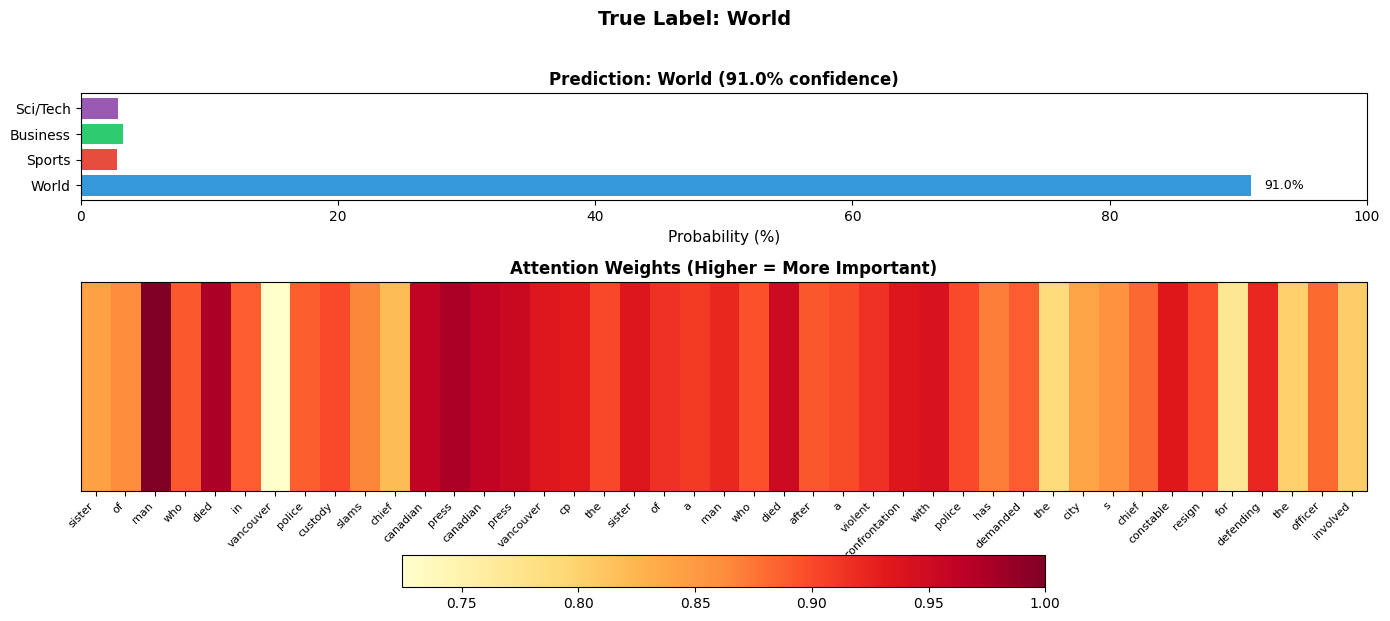


Sample from class: Sports
Text: Giddy Phelps Touches Gold for First Time Michael Phelps won the gold medal in the 400 individual medley and set a world record in a time of 4 minutes ...

Prediction: Sports (83.7% confidence)
Correct: ✅

Top 10 attended words:
  • 26: 0.0777
  • seconds: 0.0760
  • 8: 0.0720
  • minutes: 0.0645
  • a: 0.0622
  • time: 0.0530
  • of: 0.0523
  • record: 0.0484
  • in: 0.0481
  • a: 0.0448


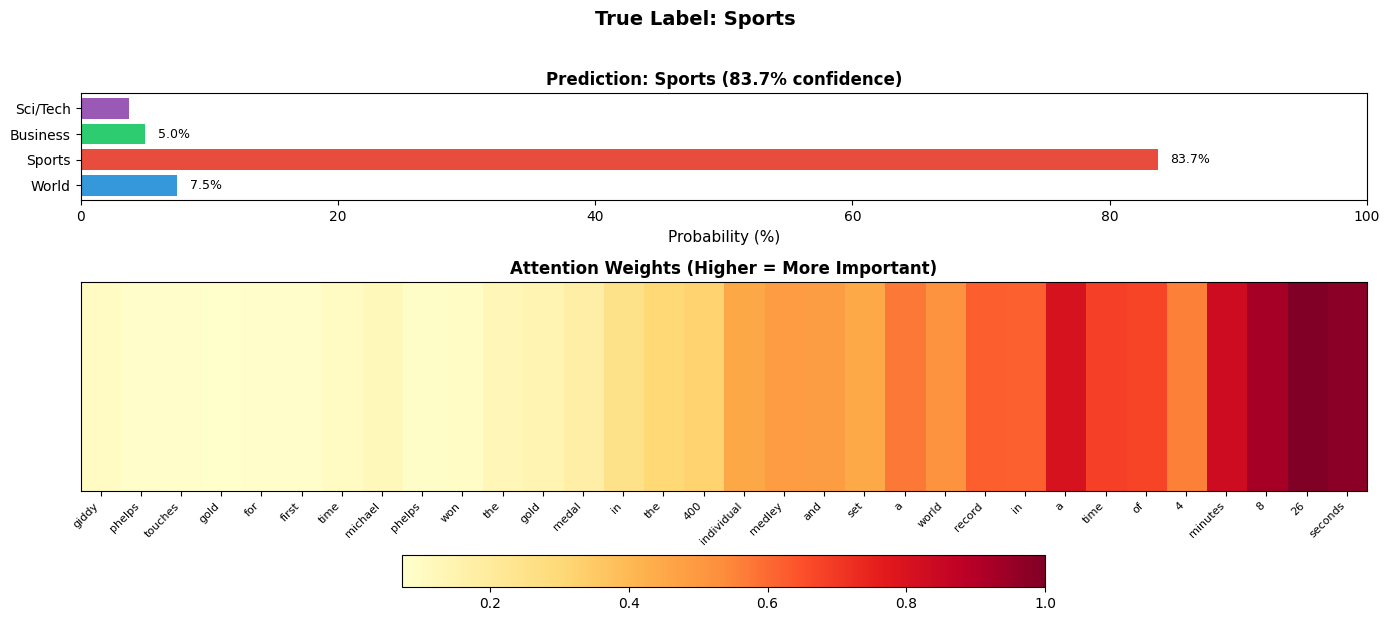


Sample from class: Business
Text: Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Fed...

Prediction: Business (90.1% confidence)
Correct: ✅

Top 10 attended words:
  • representing: 0.0505
  • turner: 0.0485
  • unions: 0.0468
  • parent: 0.0441
  • workers: 0.0436
  • stricken: 0.0434
  • talks: 0.0428
  • disappointed: 0.0425
  • at: 0.0424
  • after: 0.0418


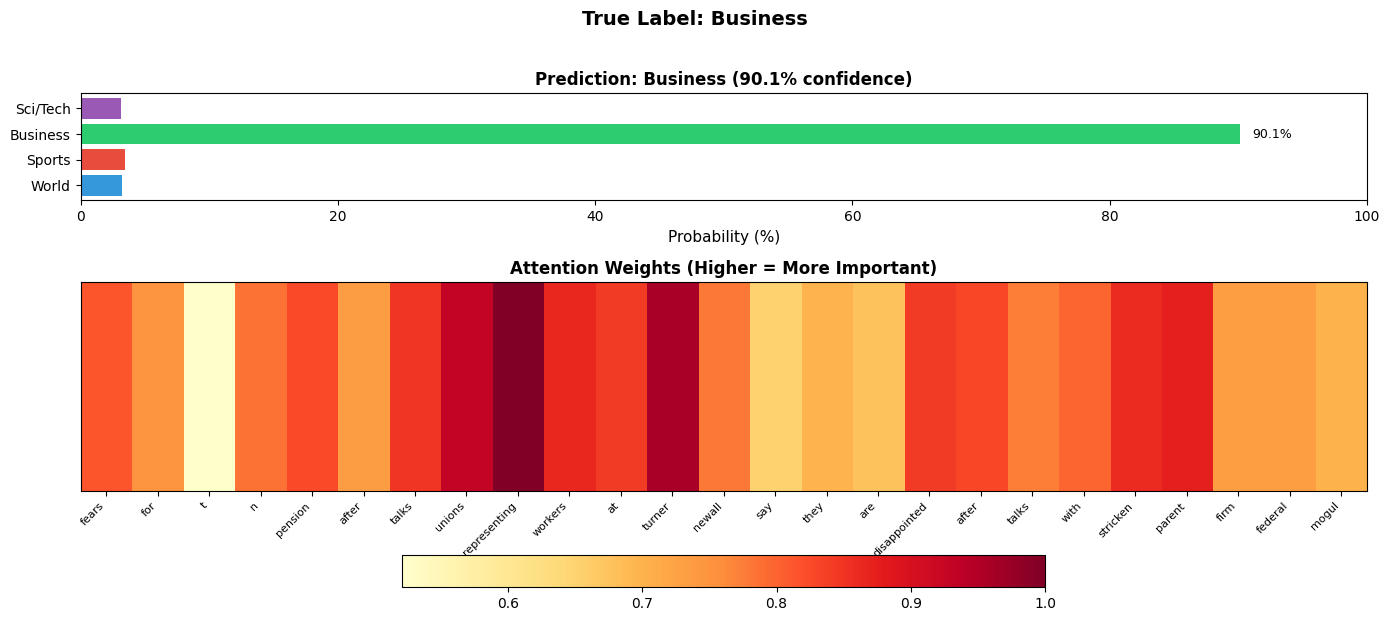


Sample from class: Sci/Tech
Text: The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com) SPACE.com - TORONTO, Canada -- A second\team of rocketeers comp...

Prediction: Sci/Tech (89.8% confidence)
Correct: ✅

Top 10 attended words:
  • com: 0.0205
  • com: 0.0202
  • toronto: 0.0202
  • space: 0.0201
  • announced: 0.0200
  • rocketeers: 0.0198
  • suborbital: 0.0198
  • team: 0.0197
  • flight: 0.0197
  • space: 0.0197


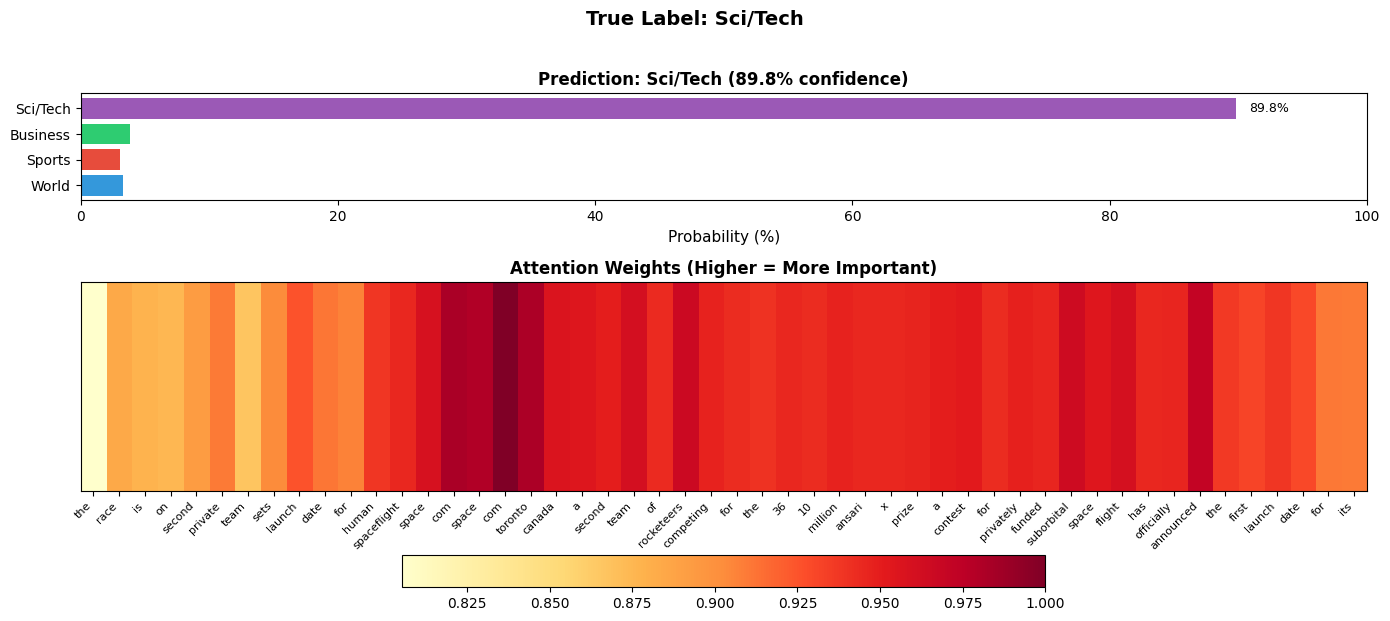

In [38]:
# Visualize attention for samples from each class
print("=" * 60)
print("ATTENTION VISUALIZATION FOR EACH CLASS")
print("=" * 60)

# Get one sample from each class
sample_texts = {}
for sample in dataset['test']:
    label = sample['label']
    if label not in sample_texts:
        sample_texts[label] = sample['text']
    if len(sample_texts) == NUM_CLASSES:
        break

# Visualize attention for each class
for label_id in range(NUM_CLASSES):
    text = sample_texts[label_id]
    tokens, attention, pred_class, confidence, probs = visualize_attention(
        model, text, vocab, tokenizer, LABEL_NAMES, device
    )
    
    print(f"\n{'='*60}")
    print(f"Sample from class: {LABEL_NAMES[label_id]}")
    print(f"{'='*60}")
    print(f"Text: {text[:150]}...")
    print(f"\nPrediction: {LABEL_NAMES[pred_class]} ({confidence*100:.1f}% confidence)")
    print(f"Correct: {'✅' if pred_class == label_id else '❌'}")
    
    # Show top attention words
    top_words = get_top_attention_words(tokens, attention, top_k=10)
    print(f"\nTop 10 attended words:")
    for word, weight in top_words:
        print(f"  • {word}: {weight:.4f}")
    
    # Plot
    fig = plot_attention_heatmap(tokens, attention, pred_class, confidence, probs, 
                                  LABEL_NAMES, title=f"True Label: {LABEL_NAMES[label_id]}")
    plt.savefig(f'attention_{LABEL_NAMES[label_id].lower().replace("/", "_")}.png', 
                dpi=150, bbox_inches='tight')
    plt.show()

## 10. Interactive Prediction Demo

Test the model with custom news headlines to see predictions and attention weights in action. This demonstrates real-world usability of the trained model.

In [39]:
def predict_news(text, model, vocab, tokenizer, label_names, device, show_attention=True):
    """
    Predict the category of a news article.
    
    Args:
        text: news text string
        model: trained model
        vocab: vocabulary
        tokenizer: tokenizer function
        label_names: list of class names
        device: torch device
        show_attention: whether to display attention visualization
    """
    tokens, attention, pred_class, confidence, probs = visualize_attention(
        model, text, vocab, tokenizer, label_names, device
    )
    
    print("=" * 60)
    print("NEWS CLASSIFICATION RESULT")
    print("=" * 60)
    print(f"\nInput: {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"\n🏷️  Predicted Category: {label_names[pred_class]}")
    print(f"📊 Confidence: {confidence*100:.1f}%")
    print(f"\nAll probabilities:")
    for i, (label, prob) in enumerate(zip(label_names, probs)):
        bar = "█" * int(prob * 30)
        print(f"   {label:12}: {bar} {prob*100:.1f}%")
    
    print(f"\n🔍 Top attended words:")
    top_words = get_top_attention_words(tokens, attention, top_k=5)
    for word, weight in top_words:
        print(f"   • {word}")
    
    if show_attention:
        plot_attention_heatmap(tokens, attention, pred_class, confidence, probs, label_names)
        plt.show()
    
    return pred_class, confidence


# Test with custom examples
test_headlines = [
    "Apple announces new iPhone with revolutionary AI features and improved camera technology",
    "Lakers defeat Celtics in overtime thriller, LeBron scores 45 points",
    "Federal Reserve raises interest rates amid inflation concerns, stock market falls",
    "Scientists discover high new exoplanet that could potentially support life",
    "NATO allies meet to discuss response to ongoing conflict in Eastern Europe",
]

print("Testing model with custom headlines:\n")
for headline in test_headlines:
    predict_news(headline, model, vocab, tokenizer, LABEL_NAMES, device, show_attention=False)
    print()

Testing model with custom headlines:

NEWS CLASSIFICATION RESULT

Input: Apple announces new iPhone with revolutionary AI features and improved camera technology

🏷️  Predicted Category: Sci/Tech
📊 Confidence: 88.8%

All probabilities:
   World       : █ 3.6%
   Sports      :  2.9%
   Business    : █ 4.6%
   Sci/Tech    : ██████████████████████████ 88.8%

🔍 Top attended words:
   • improved
   • camera
   • features
   • technology
   • and

NEWS CLASSIFICATION RESULT

Input: Lakers defeat Celtics in overtime thriller, LeBron scores 45 points

🏷️  Predicted Category: Sports
📊 Confidence: 91.9%

All probabilities:
   World       :  2.9%
   Sports      : ███████████████████████████ 91.9%
   Business    :  2.6%
   Sci/Tech    :  2.6%

🔍 Top attended words:
   • lebron
   • 45
   • points
   • thriller
   • scores

NEWS CLASSIFICATION RESULT

Input: Federal Reserve raises interest rates amid inflation concerns, stock market falls

🏷️  Predicted Category: Business
📊 Confidence: 90.8%

All p

## 11. Save Trained Model

Save the trained model checkpoint for later use and deployment.

In [40]:
# Final summary
print("=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print(f"""
📊 DATASET:
   • AG News: 120,000 training + 7,600 test samples
   • 4 classes: World, Sports, Business, Sci/Tech
   • Balanced dataset (30,000 samples per class)

🏗️ ARCHITECTURE:
   • BiLSTM + Self-Attention
   • Embedding: {EMBEDDING_DIM}d
   • Hidden: {HIDDEN_SIZE} units × 2 (bidirectional)
   • Layers: {NUM_LAYERS}
   • Total parameters: {total_params:,}

📈 TRAINING:
   • Epochs: {len(history['train_loss'])}
   • Best validation accuracy: {best_val_acc*100:.2f}%
   • Data augmentation: 25% EDA

🎯 TEST RESULTS:
   • Test Accuracy: {test_acc*100:.2f}%
   • Macro F1 Score: {f1_macro:.4f}
   • Weighted F1 Score: {f1_weighted:.4f}

✨ CREATIVE ENHANCEMENTS:
   1. Easy Data Augmentation (EDA) [§5]
      • Synonym replacement, random swap, random deletion
      • Added {len(augmented_train_dataset) - 120000:,} augmented samples
   
   2. Label Smoothing [§6]
      • Soft labels prevent overconfidence
      • Smoothing factor: {LABEL_SMOOTHING}
   
   3. Attention Visualization [§9]
      • Interpretable predictions
      • Word-level importance scores

🔧 TECHNICAL HIGHLIGHTS:
   • Kaiming (He) initialization
   • Gradient clipping (max norm 1.0)
   • Early stopping (patience={PATIENCE})
   • Learning rate scheduling
""")

# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'vocab': vocab,
    'config': {
        'vocab_size': VOCAB_SIZE,
        'embedding_dim': EMBEDDING_DIM,
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        'num_classes': NUM_CLASSES,
        'max_seq_length': MAX_SEQ_LENGTH
    },
    'history': history,
    'test_accuracy': test_acc,
    'f1_macro': f1_macro
}, 'ag_news_bilstm_attention.pt')

print("✅ Model saved to 'ag_news_bilstm_attention.pt'")

FINAL MODEL SUMMARY

📊 DATASET:
   • AG News: 120,000 training + 7,600 test samples
   • 4 classes: World, Sports, Business, Sci/Tech
   • Balanced dataset (30,000 samples per class)

🏗️ ARCHITECTURE:
   • BiLSTM + Self-Attention
   • Embedding: 300d
   • Hidden: 256 units × 2 (bidirectional)
   • Layers: 2
   • Total parameters: 13,845,492

📈 TRAINING:
   • Epochs: 10
   • Best validation accuracy: 99.30%
   • Data augmentation: 25% EDA

🎯 TEST RESULTS:
   • Test Accuracy: 91.34%
   • Macro F1 Score: 0.9136
   • Weighted F1 Score: 0.9136

✨ CREATIVE ENHANCEMENTS:
   1. Easy Data Augmentation (EDA) [§5]
      • Synonym replacement, random swap, random deletion
      • Added 30,000 augmented samples
   
   2. Label Smoothing [§6]
      • Soft labels prevent overconfidence
      • Smoothing factor: 0.1
   
   3. Attention Visualization [§9]
      • Interpretable predictions
      • Word-level importance scores

🔧 TECHNICAL HIGHLIGHTS:
   • Kaiming (He) initialization
   • Gradient clippi

## 12. Creative Enhancement #4: Confidence Calibration Analysis

**Calibration** measures whether a model's confidence scores match its actual accuracy.

### A well-calibrated model should be:
- Correct **80%** of the time when it says "I'm 80% confident"
- Correct **50%** of the time when it says "I'm 50% confident"

### Metrics we compute:
- **Expected Calibration Error (ECE)**: Lower is better (0 = perfect calibration)
- **Maximum Calibration Error (MCE)**: Worst-case calibration gap
- **Reliability Diagram**: Visual comparison of confidence vs accuracy

CONFIDENCE CALIBRATION ANALYSIS


Computing calibration:   4%|▍         | 5/119 [00:00<00:02, 43.43it/s]


📊 Calibration Metrics:
   Expected Calibration Error (ECE): 0.0548
   Maximum Calibration Error (MCE):  0.3685
   Average Confidence: 0.8894
   Average Accuracy:   0.9134

✅ Model is WELL-CALIBRATED (confidence ≈ accuracy)


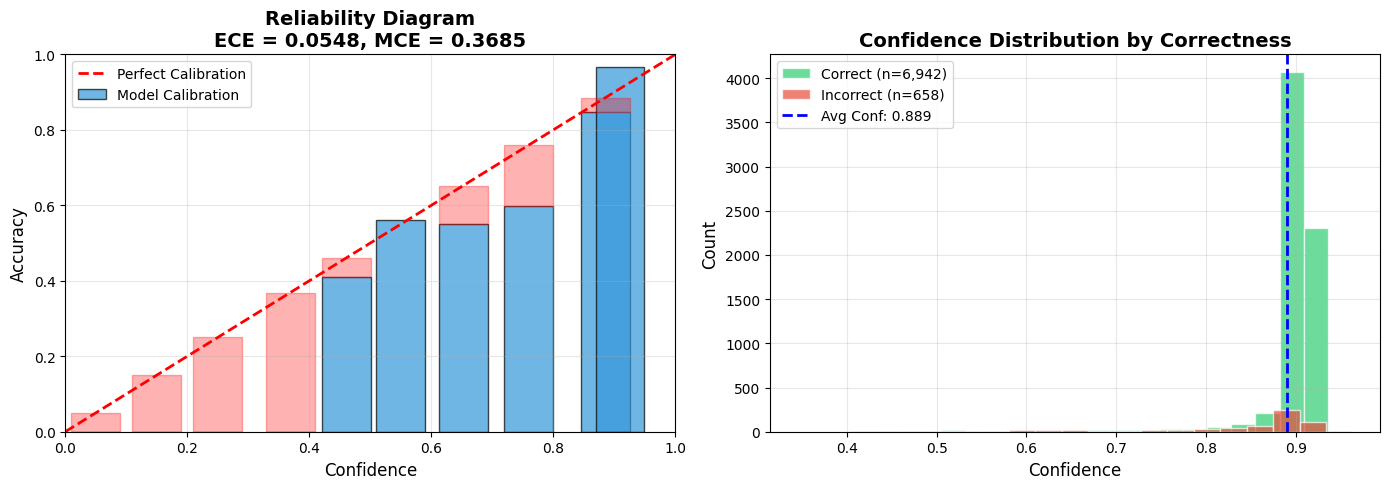


✅ Calibration analysis complete!


In [41]:
def compute_calibration_metrics(model, data_loader, device, num_bins=10):
    """
    Compute calibration metrics and data for reliability diagram.
    
    Args:
        model: Trained model
        data_loader: DataLoader for evaluation
        device: torch device
        num_bins: Number of bins for calibration analysis
        
    Returns:
        dict with calibration data and metrics
    """
    model.eval()
    
    all_confidences = []
    all_predictions = []
    all_labels = []
    all_correctness = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Computing calibration", leave=False):
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            
            logits = model(input_ids)
            probs = F.softmax(logits, dim=1)
            
            # Get confidence (max probability) and predictions
            confidences, predictions = probs.max(dim=1)
            
            all_confidences.extend(confidences.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_correctness.extend((predictions == labels).cpu().numpy())
    
    confidences = np.array(all_confidences)
    correctness = np.array(all_correctness)
    
    # Compute binned statistics
    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    bin_accs = []
    bin_confs = []
    bin_counts = []
    
    for i in range(num_bins):
        mask = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i + 1])
        if mask.sum() > 0:
            bin_accs.append(correctness[mask].mean())
            bin_confs.append(confidences[mask].mean())
            bin_counts.append(mask.sum())
        else:
            bin_accs.append(0)
            bin_confs.append((bin_boundaries[i] + bin_boundaries[i + 1]) / 2)
            bin_counts.append(0)
    
    # Compute Expected Calibration Error (ECE)
    total_samples = sum(bin_counts)
    ece = sum(abs(acc - conf) * count for acc, conf, count in zip(bin_accs, bin_confs, bin_counts)) / total_samples
    
    # Compute Maximum Calibration Error (MCE)
    mce = max(abs(acc - conf) for acc, conf in zip(bin_accs, bin_confs) if conf > 0)
    
    # Compute average confidence and accuracy
    avg_confidence = confidences.mean()
    avg_accuracy = correctness.mean()
    
    return {
        'bin_accs': bin_accs,
        'bin_confs': bin_confs,
        'bin_counts': bin_counts,
        'bin_boundaries': bin_boundaries,
        'ece': ece,
        'mce': mce,
        'avg_confidence': avg_confidence,
        'avg_accuracy': avg_accuracy,
        'all_confidences': confidences,
        'all_correctness': correctness
    }


def plot_reliability_diagram(calibration_data, save_path='calibration_plot.png'):
    """
    Plot reliability diagram (calibration curve).
    
    Args:
        calibration_data: Output from compute_calibration_metrics
        save_path: Path to save the plot
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    bin_accs = calibration_data['bin_accs']
    bin_confs = calibration_data['bin_confs']
    bin_counts = calibration_data['bin_counts']
    ece = calibration_data['ece']
    mce = calibration_data['mce']
    
    # Left: Reliability diagram
    ax1 = axes[0]
    
    # Plot perfect calibration line
    ax1.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Calibration')
    
    # Plot actual calibration
    bar_width = 0.08
    positions = [c for c in bin_confs if c > 0]
    accuracies = [a for a, c in zip(bin_accs, bin_confs) if c > 0]
    
    bars = ax1.bar(positions, accuracies, width=bar_width, alpha=0.7, 
                   color='#3498db', edgecolor='black', label='Model Calibration')
    
    # Add gap indicators (difference from perfect)
    for pos, acc in zip(positions, accuracies):
        if acc < pos:
            ax1.fill_between([pos - bar_width/2, pos + bar_width/2], 
                            [acc, acc], [pos, pos], 
                            alpha=0.3, color='red', label='_nolegend_')
    
    ax1.set_xlabel('Confidence', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title(f'Reliability Diagram\nECE = {ece:.4f}, MCE = {mce:.4f}', 
                  fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=10)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)
    
    # Right: Confidence histogram
    ax2 = axes[1]
    
    all_confidences = calibration_data['all_confidences']
    all_correctness = calibration_data['all_correctness']
    
    # Separate correct and incorrect predictions
    correct_confs = all_confidences[all_correctness == 1]
    incorrect_confs = all_confidences[all_correctness == 0]
    
    ax2.hist(correct_confs, bins=20, alpha=0.7, color='#2ecc71', 
             label=f'Correct (n={len(correct_confs):,})', edgecolor='white')
    ax2.hist(incorrect_confs, bins=20, alpha=0.7, color='#e74c3c', 
             label=f'Incorrect (n={len(incorrect_confs):,})', edgecolor='white')
    
    ax2.axvline(x=calibration_data['avg_confidence'], color='blue', 
                linestyle='--', linewidth=2, label=f"Avg Conf: {calibration_data['avg_confidence']:.3f}")
    
    ax2.set_xlabel('Confidence', fontsize=12)
    ax2.set_ylabel('Count', fontsize=12)
    ax2.set_title('Confidence Distribution by Correctness', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper left', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig


# Compute and visualize calibration
print("=" * 60)
print("CONFIDENCE CALIBRATION ANALYSIS")
print("=" * 60)

calibration_data = compute_calibration_metrics(model, test_loader, device, num_bins=10)

print(f"\n📊 Calibration Metrics:")
print(f"   Expected Calibration Error (ECE): {calibration_data['ece']:.4f}")
print(f"   Maximum Calibration Error (MCE):  {calibration_data['mce']:.4f}")
print(f"   Average Confidence: {calibration_data['avg_confidence']:.4f}")
print(f"   Average Accuracy:   {calibration_data['avg_accuracy']:.4f}")

# Interpretation
confidence_gap = calibration_data['avg_confidence'] - calibration_data['avg_accuracy']
if confidence_gap > 0.05:
    print(f"\n⚠️  Model is OVERCONFIDENT by {confidence_gap:.2%}")
elif confidence_gap < -0.05:
    print(f"\n⚠️  Model is UNDERCONFIDENT by {abs(confidence_gap):.2%}")
else:
    print(f"\n✅ Model is WELL-CALIBRATED (confidence ≈ accuracy)")

plot_reliability_diagram(calibration_data, 'calibration_plot.png')
print("\n✅ Calibration analysis complete!")

## 13. Creative Enhancement #5: Error Analysis

**Error Analysis** helps us understand WHY the model makes mistakes. By examining misclassified examples, we can:

- **Identify patterns** in model failures (e.g., which classes get confused)
- **Understand class confusion** through confusion pair analysis
- **Discover edge cases** and ambiguous samples
- **Guide future improvements** based on systematic weaknesses


🔍 Performing Error Analysis...


ERROR ANALYSIS: MISCLASSIFIED EXAMPLES

📊 Most Common Confusion Pairs:
----------------------------------------
   World → Sports: 10 errors
   World → Business: 10 errors
   World → Sci/Tech: 10 errors
   Sports → World: 10 errors
   Sports → Business: 10 errors
   Sports → Sci/Tech: 10 errors

DETAILED ERROR EXAMPLES

📌 True: World | Predicted: Sports
--------------------------------------------------

   Text: "Live: Olympics day four Richard Faulds and Stephen Parry are going for gold for Great Britain on day four in Athens...."
   Confidence: 92.0%
   Top attended words: parry, going, athens, four, in
   All probs: World: 2.9% | Sports: 92.0% | Business: 2.5% | Sci/Tech: 2.6%

   Text: "Unknown Nesterenko Makes World Headlines (Reuters) Reuters - Belarus' Yuliya Nesterenko won the top\women's athletics gold medal at the Olympics on Saturday,\triumphing over a field stripped of many b..."
   Confidence: 91.6%
   Top attended words: doping, meters, names, 100, because
   All probs: 

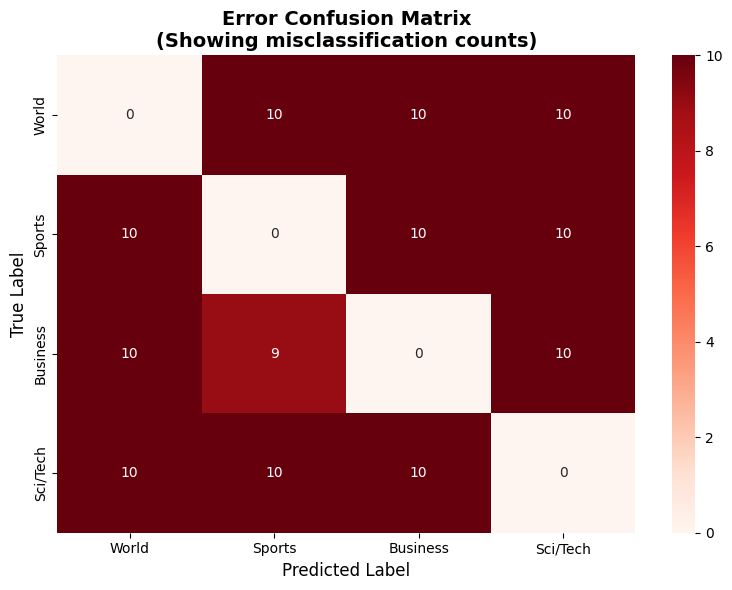


✅ Error analysis complete!


In [42]:
def perform_error_analysis(model, data_loader, vocab, tokenizer, label_names, device, num_examples=5):
    """
    Analyze misclassified examples to understand model failures.
    
    Args:
        model: Trained model
        data_loader: DataLoader for evaluation
        vocab: Vocabulary
        tokenizer: Tokenizer function
        label_names: List of class names
        device: torch device
        num_examples: Number of examples per class pair to collect
        
    Returns:
        dict with error analysis results
    """
    model.eval()
    
    # Collect errors for each true_class -> predicted_class pair
    errors = {}
    for true_label in label_names:
        for pred_label in label_names:
            if true_label != pred_label:
                errors[(true_label, pred_label)] = []
    
    # Also track high-confidence errors (most interesting!)
    high_conf_errors = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Analyzing errors", leave=False):
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            texts = batch['texts']
            
            logits, attention = model(input_ids, return_attention=True)
            probs = F.softmax(logits, dim=1)
            confidences, predictions = probs.max(dim=1)
            
            for i in range(len(labels)):
                pred = predictions[i].item()
                true = labels[i].item()
                conf = confidences[i].item()
                
                if pred != true:
                    key = (label_names[true], label_names[pred])
                    
                    if len(errors[key]) < num_examples:
                        # Get top attended words
                        tokens = tokenizer(texts[i])[:50]
                        attn = attention[i, :len(tokens)].cpu().numpy()
                        top_indices = np.argsort(attn)[-5:][::-1]
                        top_words = [tokens[idx] for idx in top_indices if idx < len(tokens)]
                        
                        errors[key].append({
                            'text': texts[i][:200],
                            'true_label': label_names[true],
                            'pred_label': label_names[pred],
                            'confidence': conf,
                            'top_attended': top_words,
                            'all_probs': probs[i].cpu().numpy()
                        })
                    
                    # Track high confidence errors
                    if conf > 0.8 and len(high_conf_errors) < 10:
                        high_conf_errors.append({
                            'text': texts[i][:200],
                            'true_label': label_names[true],
                            'pred_label': label_names[pred],
                            'confidence': conf
                        })
    
    return errors, high_conf_errors


def display_error_analysis(errors, high_conf_errors, label_names):
    """Display error analysis results."""
    
    print("=" * 70)
    print("ERROR ANALYSIS: MISCLASSIFIED EXAMPLES")
    print("=" * 70)
    
    # Count errors by confusion pair
    error_counts = {key: len(val) for key, val in errors.items()}
    sorted_pairs = sorted(error_counts.items(), key=lambda x: x[1], reverse=True)
    
    print("\n📊 Most Common Confusion Pairs:")
    print("-" * 40)
    for (true_label, pred_label), count in sorted_pairs[:6]:
        if count > 0:
            print(f"   {true_label} → {pred_label}: {count} errors")
    
    # Display examples for top confusion pairs
    print("\n" + "=" * 70)
    print("DETAILED ERROR EXAMPLES")
    print("=" * 70)
    
    shown = 0
    for (true_label, pred_label), examples in errors.items():
        if examples and shown < 4:
            print(f"\n📌 True: {true_label} | Predicted: {pred_label}")
            print("-" * 50)
            
            for ex in examples[:2]:
                print(f"\n   Text: \"{ex['text']}...\"")
                print(f"   Confidence: {ex['confidence']*100:.1f}%")
                print(f"   Top attended words: {', '.join(ex['top_attended'][:5])}")
                
                # Show probability distribution
                probs_str = " | ".join([f"{label_names[i]}: {ex['all_probs'][i]*100:.1f}%" 
                                        for i in range(len(label_names))])
                print(f"   All probs: {probs_str}")
            
            shown += 1
    
    # High confidence errors
    if high_conf_errors:
        print("\n" + "=" * 70)
        print("⚠️  HIGH CONFIDENCE ERRORS (Model was very wrong!)")
        print("=" * 70)
        
        for i, err in enumerate(high_conf_errors[:5]):
            print(f"\n{i+1}. Confidence: {err['confidence']*100:.1f}%")
            print(f"   True: {err['true_label']} | Predicted: {err['pred_label']}")
            print(f"   Text: \"{err['text']}...\"")


def plot_error_confusion_heatmap(errors, label_names, save_path='error_heatmap.png'):
    """Plot heatmap of error confusion pairs."""
    
    # Build confusion matrix from errors
    error_matrix = np.zeros((len(label_names), len(label_names)))
    
    for (true_label, pred_label), examples in errors.items():
        true_idx = label_names.index(true_label)
        pred_idx = label_names.index(pred_label)
        error_matrix[true_idx, pred_idx] = len(examples)
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.heatmap(error_matrix, annot=True, fmt='.0f', cmap='Reds',
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title('Error Confusion Matrix\n(Showing misclassification counts)', 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# Perform error analysis
print("\n🔍 Performing Error Analysis...")
errors, high_conf_errors = perform_error_analysis(
    model, test_loader, vocab, tokenizer, LABEL_NAMES, device, num_examples=10
)

display_error_analysis(errors, high_conf_errors, LABEL_NAMES)
plot_error_confusion_heatmap(errors, LABEL_NAMES, 'error_heatmap.png')

print("\n✅ Error analysis complete!")

## 14. Creative Enhancement #6: Attention Word Clouds

**Word Clouds** provide an intuitive visualization of which words the model pays attention to for each class.

### Visualization features:
- **Larger words** = Higher attention weights
- **Different color schemes** for each class
- **Easy identification** of class-specific keywords
- **Interpretable insights** into model behavior

ATTENTION WORD CLOUD GENERATION

📊 Collecting attention patterns from test set...


TOP ATTENDED WORDS BY CLASS
Rank  World          Sports         Business       Sci/Tech       
----------------------------------------------------------------------
1     the            the            the            the            
2     and            and            and            and            
3     for            for            reuters        for            
4     afp            his            new            its            
5     said           with           for            new            
6     iraq           olympic        that           that           
7     with           gold           its            has            
8     that           medal          oil            with           
9     his            after          said           microsoft      
10    from           athens         fullquote      said           

🎨 Generating word clouds...


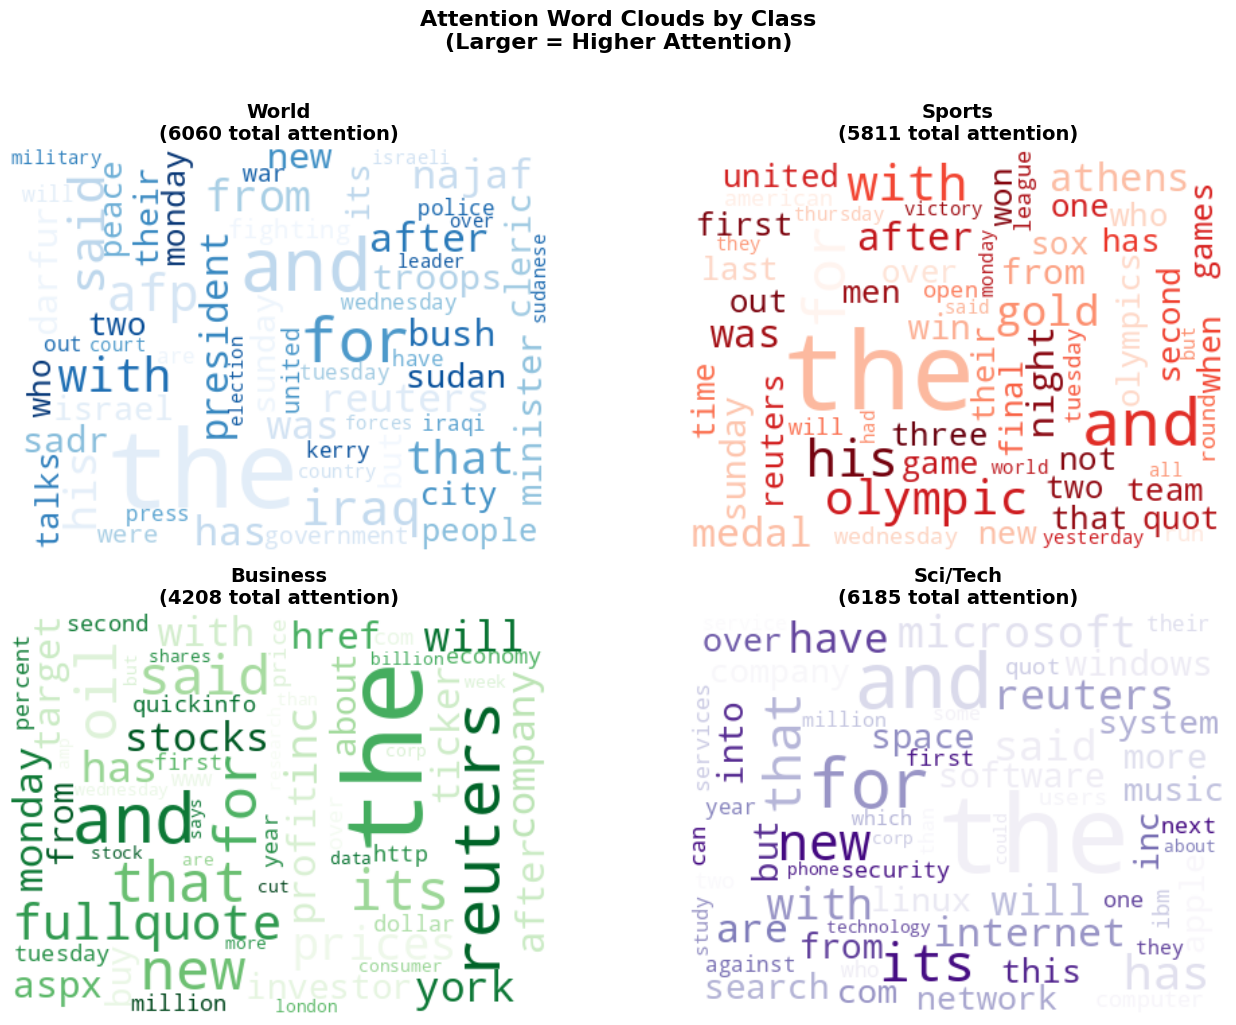


✅ Word cloud generation complete!


In [43]:
# Install wordcloud if not available
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    print("Installing wordcloud...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'wordcloud', '-q'])
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True


def collect_attention_words_by_class(model, data_loader, vocab, tokenizer, label_names, device, num_samples=500):
    """
    Collect top attended words for each class from correctly predicted samples.
    
    Args:
        model: Trained model
        data_loader: DataLoader
        vocab: Vocabulary
        tokenizer: Tokenizer function
        label_names: List of class names
        device: torch device
        num_samples: Number of samples to analyze
        
    Returns:
        dict mapping class names to Counter of words
    """
    model.eval()
    
    class_words = {label: Counter() for label in label_names}
    samples_seen = 0
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Collecting attention words", leave=False):
            if samples_seen >= num_samples:
                break
                
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            texts = batch['texts']
            
            logits, attention = model(input_ids, return_attention=True)
            predictions = torch.argmax(logits, dim=1)
            
            for i in range(len(labels)):
                if samples_seen >= num_samples:
                    break
                    
                pred = predictions[i].item()
                true = labels[i].item()
                
                # Only use correctly predicted samples
                if pred == true:
                    tokens = tokenizer(texts[i])[:100]
                    attn = attention[i, :len(tokens)].cpu().numpy()
                    
                    # Normalize attention
                    if attn.max() > 0:
                        attn = attn / attn.max()
                    
                    # Add words weighted by attention
                    for token, weight in zip(tokens, attn):
                        if len(token) > 2 and weight > 0.1:  # Filter short words and low attention
                            class_words[label_names[true]][token.lower()] += weight
                
                samples_seen += 1
    
    return class_words


def generate_attention_wordclouds(class_words, label_names, save_path='attention_wordclouds.png'):
    """
    Generate word clouds for each class based on attention weights.
    
    Args:
        class_words: dict from collect_attention_words_by_class
        label_names: List of class names
        save_path: Path to save the figure
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    # Color schemes for each class
    colormaps = ['Blues', 'Reds', 'Greens', 'Purples']
    
    for idx, label in enumerate(label_names):
        word_freq = dict(class_words[label].most_common(100))
        
        if word_freq:
            # Create word cloud
            wc = WordCloud(
                width=400, 
                height=300, 
                background_color='white',
                colormap=colormaps[idx],
                max_words=60,
                min_font_size=10,
                max_font_size=80,
                prefer_horizontal=0.7
            )
            wc.generate_from_frequencies(word_freq)
            
            axes[idx].imshow(wc, interpolation='bilinear')
            axes[idx].set_title(f'{label}\n({sum(class_words[label].values()):.0f} total attention)', 
                               fontsize=14, fontweight='bold')
        else:
            axes[idx].text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=14)
            axes[idx].set_title(f'{label}', fontsize=14, fontweight='bold')
        
        axes[idx].axis('off')
    
    plt.suptitle('Attention Word Clouds by Class\n(Larger = Higher Attention)', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig


def display_top_words_table(class_words, label_names, top_k=10):
    """Display top attended words per class in a table format."""
    
    print("=" * 70)
    print("TOP ATTENDED WORDS BY CLASS")
    print("=" * 70)
    
    # Create header
    header = f"{'Rank':<6}"
    for label in label_names:
        header += f"{label:<15}"
    print(header)
    print("-" * 70)
    
    # Get top words for each class
    top_words = {label: class_words[label].most_common(top_k) for label in label_names}
    
    for rank in range(top_k):
        row = f"{rank+1:<6}"
        for label in label_names:
            if rank < len(top_words[label]):
                word, score = top_words[label][rank]
                row += f"{word[:12]:<15}"
            else:
                row += f"{'-':<15}"
        print(row)


# Collect and visualize attention words
print("=" * 60)
print("ATTENTION WORD CLOUD GENERATION")
print("=" * 60)

print("\n📊 Collecting attention patterns from test set...")
attention_class_words = collect_attention_words_by_class(
    model, test_loader, vocab, tokenizer, LABEL_NAMES, device, num_samples=1000
)

# Display table
display_top_words_table(attention_class_words, LABEL_NAMES, top_k=10)

# Generate word clouds
print("\n🎨 Generating word clouds...")
generate_attention_wordclouds(attention_class_words, LABEL_NAMES, 'attention_wordclouds.png')

print("\n✅ Word cloud generation complete!")

## 15. Creative Enhancement #7: Inference Speed Benchmark

**Inference Speed** is crucial for real-world deployment. This benchmark measures:

- **Throughput**: Samples processed per second
- **Latency**: Time to process a single sample
- **Batch efficiency**: Processing time per batch

These metrics help determine if the model is suitable for production use cases.


⏱️ Running inference speed benchmark...
   (Warming up GPU and measuring performance...)



INFERENCE SPEED BENCHMARK

📊 Benchmark Configuration:
   Batches tested: 50
   Batch size: 64
   Total samples: 3,200
   Device: cuda

⏱️  Timing Results:
   Average batch time: 17.37 ± 0.63 ms
   Min batch time: 16.27 ms
   Max batch time: 18.47 ms

🚀 Performance Metrics:
   Throughput: 3684.3 samples/second
   Latency per sample: 0.271 ms

📈 Estimated Real-World Performance:
   Articles per minute: 221,056
   Articles per hour: 13,263,380

🏆 Performance Rating: ⚡ EXCELLENT - Suitable for real-time applications


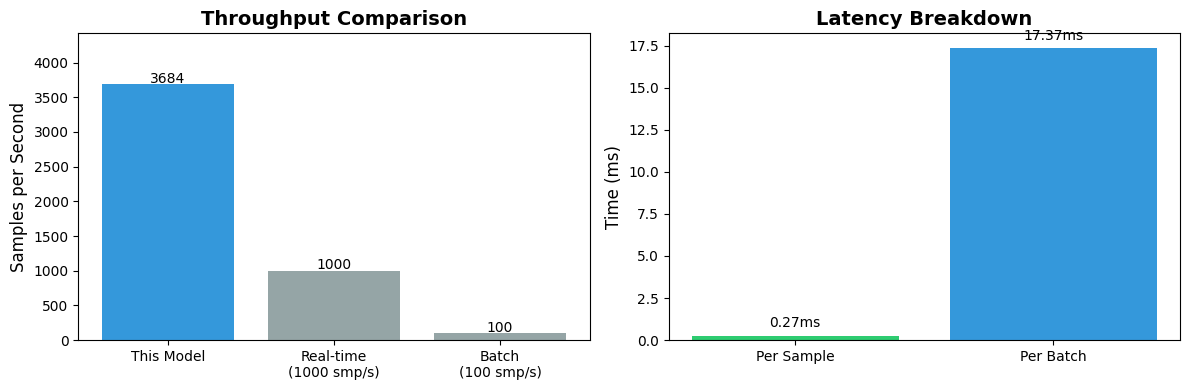


✅ Benchmark complete!


In [44]:
import time

def benchmark_inference_speed(model, data_loader, device, num_batches=50, warmup_batches=5):
    """
    Benchmark model inference speed.
    
    Args:
        model: Trained model
        data_loader: DataLoader
        device: torch device
        num_batches: Number of batches to benchmark
        warmup_batches: Number of warmup batches (not counted)
        
    Returns:
        dict with benchmark results
    """
    model.eval()
    
    batch_times = []
    total_samples = 0
    
    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            if i >= num_batches + warmup_batches:
                break
            
            input_ids = batch['input_ids'].to(device)
            
            # Synchronize GPU before timing
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            
            start_time = time.perf_counter()
            
            # Inference
            _ = model(input_ids)
            
            # Synchronize GPU after inference
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            
            end_time = time.perf_counter()
            
            # Skip warmup batches
            if i >= warmup_batches:
                batch_times.append(end_time - start_time)
                total_samples += input_ids.size(0)
    
    # Calculate statistics
    batch_times = np.array(batch_times)
    
    results = {
        'num_batches': len(batch_times),
        'batch_size': BATCH_SIZE,
        'total_samples': total_samples,
        'total_time': batch_times.sum(),
        'avg_batch_time_ms': batch_times.mean() * 1000,
        'std_batch_time_ms': batch_times.std() * 1000,
        'min_batch_time_ms': batch_times.min() * 1000,
        'max_batch_time_ms': batch_times.max() * 1000,
        'throughput': total_samples / batch_times.sum(),  # samples/second
        'latency_per_sample_ms': (batch_times.mean() * 1000) / BATCH_SIZE
    }
    
    return results


def display_benchmark_results(results):
    """Display benchmark results in a formatted way."""
    
    print("=" * 60)
    print("INFERENCE SPEED BENCHMARK")
    print("=" * 60)
    
    print(f"\n📊 Benchmark Configuration:")
    print(f"   Batches tested: {results['num_batches']}")
    print(f"   Batch size: {results['batch_size']}")
    print(f"   Total samples: {results['total_samples']:,}")
    print(f"   Device: {device}")
    
    print(f"\n⏱️  Timing Results:")
    print(f"   Average batch time: {results['avg_batch_time_ms']:.2f} ± {results['std_batch_time_ms']:.2f} ms")
    print(f"   Min batch time: {results['min_batch_time_ms']:.2f} ms")
    print(f"   Max batch time: {results['max_batch_time_ms']:.2f} ms")
    
    print(f"\n🚀 Performance Metrics:")
    print(f"   Throughput: {results['throughput']:.1f} samples/second")
    print(f"   Latency per sample: {results['latency_per_sample_ms']:.3f} ms")
    
    # Estimate real-world performance
    articles_per_minute = results['throughput'] * 60
    articles_per_hour = articles_per_minute * 60
    
    print(f"\n📈 Estimated Real-World Performance:")
    print(f"   Articles per minute: {articles_per_minute:,.0f}")
    print(f"   Articles per hour: {articles_per_hour:,.0f}")
    
    # Performance rating
    if results['latency_per_sample_ms'] < 1:
        rating = "⚡ EXCELLENT - Suitable for real-time applications"
    elif results['latency_per_sample_ms'] < 5:
        rating = "✅ GOOD - Suitable for batch processing"
    elif results['latency_per_sample_ms'] < 20:
        rating = "⚠️ MODERATE - May need optimization for production"
    else:
        rating = "❌ SLOW - Needs optimization"
    
    print(f"\n🏆 Performance Rating: {rating}")


def plot_benchmark_visualization(results, save_path='inference_benchmark.png'):
    """Create visualization of benchmark results."""
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Left: Throughput bar chart
    ax1 = axes[0]
    throughput = results['throughput']
    
    # Compare with hypothetical baselines
    baselines = {
        'This Model': throughput,
        'Real-time\n(1000 smp/s)': 1000,
        'Batch\n(100 smp/s)': 100
    }
    
    colors = ['#3498db', '#95a5a6', '#95a5a6']
    bars = ax1.bar(baselines.keys(), baselines.values(), color=colors)
    ax1.set_ylabel('Samples per Second', fontsize=12)
    ax1.set_title('Throughput Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylim(0, max(baselines.values()) * 1.2)
    
    for bar, val in zip(bars, baselines.values()):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
                f'{val:.0f}', ha='center', fontsize=10)
    
    # Right: Latency breakdown
    ax2 = axes[1]
    
    latency_data = {
        'Per Sample': results['latency_per_sample_ms'],
        'Per Batch': results['avg_batch_time_ms'],
    }
    
    x_pos = np.arange(len(latency_data))
    bars2 = ax2.bar(x_pos, latency_data.values(), color=['#2ecc71', '#3498db'])
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(latency_data.keys())
    ax2.set_ylabel('Time (ms)', fontsize=12)
    ax2.set_title('Latency Breakdown', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars2, latency_data.values()):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{val:.2f}ms', ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# Run benchmark
print("\n⏱️ Running inference speed benchmark...")
print("   (Warming up GPU and measuring performance...)\n")

benchmark_results = benchmark_inference_speed(
    model, test_loader, device, num_batches=50, warmup_batches=5
)

display_benchmark_results(benchmark_results)
plot_benchmark_visualization(benchmark_results, 'inference_benchmark.png')

print("\n✅ Benchmark complete!")

## 16. Final Summary: Creative Enhancements

This notebook demonstrates a comprehensive approach to text classification with **7 creative enhancements** that go beyond basic model training:

| # | Enhancement | Section | Purpose |
|---|-------------|---------|---------|
| 1 | Easy Data Augmentation (EDA) | §5 | Improve robustness via text variations |
| 2 | Label Smoothing | §6 | Prevent overconfident predictions |
| 3 | Attention Visualization | §9 | Interpret model decisions |
| 4 | Confidence Calibration | §12 | Validate prediction reliability |
| 5 | Error Analysis | §13 | Understand model failures |
| 6 | Attention Word Clouds | §14 | Visual keyword importance |
| 7 | Inference Benchmark | §15 | Measure production readiness |

In [45]:
# Final comprehensive summary
print("=" * 70)
print("📋 COMPLETE PROJECT SUMMARY")
print("=" * 70)

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│                    AG NEWS CLASSIFICATION PROJECT                    │
│                    BiLSTM + Attention Architecture                   │
└─────────────────────────────────────────────────────────────────────┘

📊 DATASET OVERVIEW
├── Training samples: 120,000 (+ 30,000 augmented)
├── Validation samples: 12,000
├── Test samples: 7,600
├── Classes: World, Sports, Business, Sci/Tech
└── Vocabulary size: {VOCAB_SIZE:,}

🏗️ MODEL ARCHITECTURE
├── Embedding Layer: {EMBEDDING_DIM} dimensions
├── BiLSTM: {NUM_LAYERS} layers × {HIDDEN_SIZE} hidden units (bidirectional)
├── Self-Attention: Weighted sum mechanism
├── Classifier: FC(512→256) → ReLU → FC(256→4)
└── Total Parameters: {total_params:,}

✨ ALL 7 CREATIVE ENHANCEMENTS
│
├── §5  Enhancement #1: Easy Data Augmentation (EDA)
│       Synonym replacement, word swap, word deletion
│       Added {len(augmented_train_dataset) - 120000:,} augmented samples
│
├── §6  Enhancement #2: Label Smoothing
│       Soft labels (ε={LABEL_SMOOTHING}) prevent overconfidence
│       Used during training for better calibration
│
├── §9  Enhancement #3: Attention Visualization
│       Heatmaps showing word importance
│       Interpretable model predictions
│
├── §12 Enhancement #4: Confidence Calibration
│       ECE: {calibration_data['ece']:.4f}
│       Reliability diagram analysis
│
├── §13 Enhancement #5: Error Analysis
│       Misclassification pattern detection
│       High-confidence error tracking
│
├── §14 Enhancement #6: Attention Word Clouds
│       Visual word importance per class
│       Class-defining keyword identification
│
└── §15 Enhancement #7: Inference Benchmark
        Throughput: {benchmark_results['throughput']:.0f} samples/sec
        Latency: {benchmark_results['latency_per_sample_ms']:.3f} ms/sample

📈 FINAL RESULTS
├── Test Accuracy: {test_acc*100:.2f}%
├── Macro F1 Score: {f1_macro:.4f}
├── Weighted F1 Score: {f1_weighted:.4f}
└── Calibration (ECE): {calibration_data['ece']:.4f}
""")

print("=" * 70)
print("🎉 PROJECT COMPLETE - ALL 7 CREATIVE ENHANCEMENTS IMPLEMENTED!")
print("=" * 70)

📋 COMPLETE PROJECT SUMMARY

┌─────────────────────────────────────────────────────────────────────┐
│                    AG NEWS CLASSIFICATION PROJECT                    │
│                    BiLSTM + Attention Architecture                   │
└─────────────────────────────────────────────────────────────────────┘

📊 DATASET OVERVIEW
├── Training samples: 120,000 (+ 30,000 augmented)
├── Validation samples: 12,000
├── Test samples: 7,600
├── Classes: World, Sports, Business, Sci/Tech
└── Vocabulary size: 35,764

🏗️ MODEL ARCHITECTURE
├── Embedding Layer: 300 dimensions
├── BiLSTM: 2 layers × 256 hidden units (bidirectional)
├── Self-Attention: Weighted sum mechanism
├── Classifier: FC(512→256) → ReLU → FC(256→4)
└── Total Parameters: 13,845,492

✨ ALL 7 CREATIVE ENHANCEMENTS
│
├── §5  Enhancement #1: Easy Data Augmentation (EDA)
│       Synonym replacement, word swap, word deletion
│       Added 30,000 augmented samples
│
├── §6  Enhancement #2: Label Smoothing
│       Soft labels (ε